In [441]:
import geopandas as gpd
import os
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from datetime import timedelta


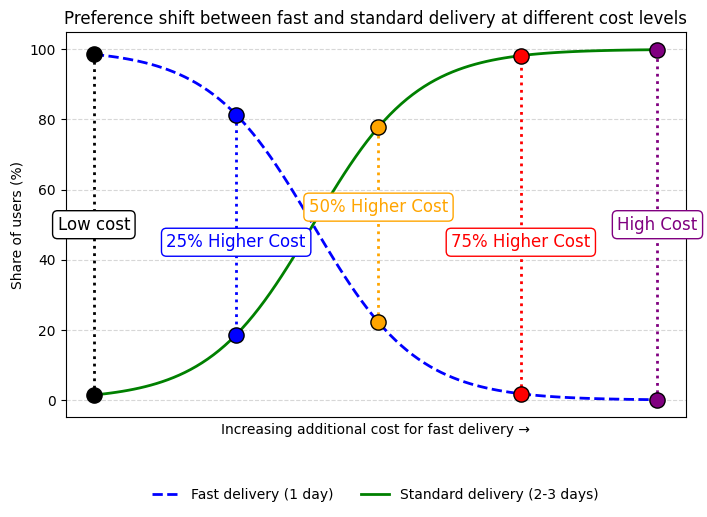

In [2]:
# Plot from EWGT 2025 Abstract

# Define price values (cost increasing)
price = np.linspace(1, 10, 100)  # Price from 1 to 10

# Demand distribution between fast and standard delivery (summing to 100%)
fast_delivery_share = 100 / (1 + np.exp(1.2 * (price - 4.5)))  # Fast delivery preference decreases with price
standard_delivery_share = 100 - fast_delivery_share  # Standard delivery preference increases accordingly

# Define cost-based sample points at 0%, 25%, 50%, 75%, and 100% of the cost range
cost_levels = [0.0, 0.25, 0.50, 0.75, 0.99]  # Avoid index out of range by using 0.99 instead of 1.0
sample_prices = [price[int(len(price) * c)] for c in cost_levels]  # Select corresponding price points

# Compute the corresponding fast and standard delivery shares
fast_shares = [fast_delivery_share[np.argmin(np.abs(price - p))] for p in sample_prices]
standard_shares = [100 - fs for fs in fast_shares]

# Define colors for scenarios
scenario_colors = ["black", "blue", "orange", "red", "purple"]
# Define updated labels based on cost levels rather than share percentages
scenario_labels = ["Low cost", "25% Higher Cost", "50% Higher Cost", "75% Higher Cost", "High Cost"]


label_offsets = [0, -5, 5, -5, 0]  # Adjust vertical position of text labels

# Create the plot again with improved label placement
plt.figure(figsize=(8, 5))
plt.plot(price, fast_delivery_share, label="Fast delivery (1 day)", linewidth=2, linestyle="dashed", color="blue")
plt.plot(price, standard_delivery_share, label="Standard delivery (2-3 days)", linewidth=2, color="green")

# Mark sample scenarios with same-colored points and connect them with vertical dashed lines
for i, (p, f, s) in enumerate(zip(sample_prices, fast_shares, standard_shares)):
    plt.scatter(p, f, color=scenario_colors[i], s=120, edgecolors="black", zorder=3)  # Fast delivery point
    plt.scatter(p, s, color=scenario_colors[i], s=120, edgecolors="black", zorder=3)  # Standard delivery point
    plt.plot([p, p], [f, s], color=scenario_colors[i], linestyle="dotted", linewidth=2, zorder=2)  # Vertical connector
    plt.text(p, (f + s) / 2 + label_offsets[i], scenario_labels[i], fontsize=12, color=scenario_colors[i],
             ha="center", va="center", bbox=dict(facecolor="white", edgecolor=scenario_colors[i], boxstyle="round,pad=0.3"))

# Adjust labels
plt.xlabel("Increasing additional cost for fast delivery →")
plt.ylabel("Share of users (%)")
plt.title("Preference shift between fast and standard delivery at different cost levels")

# Grid and legend below the plot
plt.grid(True, linestyle="dashed", alpha=0.5)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Remove x-axis ticks
plt.xticks([])

plt.show()



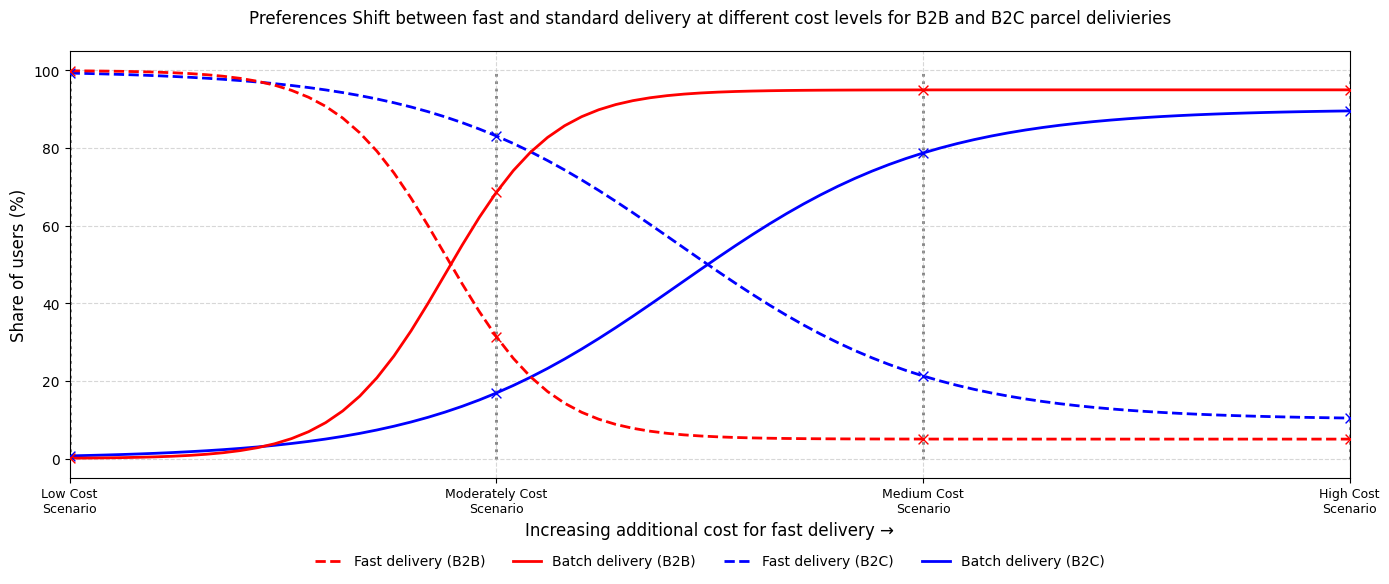

In [176]:
# Jetzt: Vertikale Linien = Szenariofarbe | Kreuze = Linienfarbe (B2B/Neutral/B2C)
import numpy as np
import matplotlib.pyplot as plt

# Preisachse
price = np.linspace(1, 10, 100)

# Preis minimal verschieben für Modellierung
price_shifted = price - 1.25

# B2C-Modell
fast_delivery_b2c = 10 + (90) / (1 + np.exp(1.5 * (price_shifted - 3)))
batch_delivery_b2c = 100 - fast_delivery_b2c

# B2B-Modell
fast_delivery_b2b = 5 + (95) / (1 + np.exp(3.5 * (price_shifted - 1.75)))
batch_delivery_b2b = 100 - fast_delivery_b2b

# Cost levels
cost_levels = [0.0, 0.25, 0.5, 0.75]  # Nur vier Punkte

sample_prices = [price[int(len(price) * c)] for c in cost_levels]

scenario_labels = [
    "Low Cost\nScenario",
    "Moderately Cost\nScenario",
    "Medium Cost\nScenario",
    "High Cost\nScenario"
]

# Scenario colors for vertical lines
scenario_colors = ["black", "blue", "red", "red", "purple"]

# Curve colors for crosses
curve_colors = {
    "fast_b2c": "blue",
    "batch_b2c": "blue",
    "fast_neutral": "green",
    "batch_neutral": "green",
    "fast_b2b": "red",
    "batch_b2b": "red"
}

# Create the plot
plt.figure(figsize=(14, 6))

# Plot curves
plt.plot(price, fast_delivery_b2c, linestyle="--", color="blue", linewidth=2, label="Fast delivery (B2C)")
plt.plot(price, batch_delivery_b2c, linestyle="-", color="blue", linewidth=2, label="Batch delivery (B2C)")

# plt.plot(price, fast_delivery_neutral, linestyle="--", color="green", linewidth=2, label="Fast delivery (Neutral)")
# plt.plot(price, batch_delivery_neutral, linestyle="-", color="green", linewidth=2, label="Batch delivery (Neutral)")

plt.plot(price, fast_delivery_b2b, linestyle="--", color="red", linewidth=2, label="Fast delivery (B2B)")
plt.plot(price, batch_delivery_b2b, linestyle="-", color="red", linewidth=2, label="Batch delivery (B2B)")

# Add vertical lines and crosses at intersections
for i, p in enumerate(sample_prices):
    scenario_color = scenario_colors[i]
    
    # Vertical line from 0 to 100 in scenario color
    plt.plot([p, p], [0, 100], color="gray", linestyle="dotted", linewidth=2, zorder=1)
    
    # Find closest index
    idx = np.argmin(np.abs(price - p))
    
    # Plot crosses in curve color
    plt.scatter(p, fast_delivery_b2c[idx], color=curve_colors["fast_b2c"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2c[idx], color=curve_colors["batch_b2c"], marker='x', s=50, linewidths=1, zorder=3)

    
    plt.scatter(p, fast_delivery_b2b[idx], color=curve_colors["fast_b2b"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2b[idx], color=curve_colors["batch_b2b"], marker='x', s=50, linewidths=1, zorder=3)

# Style settings
plt.xlabel("Increasing additional cost for fast delivery →", fontsize=12)
plt.xticks(sample_prices, scenario_labels, rotation=00, ha="center", fontsize=9)

plt.ylabel("Share of users (%)", fontsize=12)
plt.title("Preferences Shift between fast and standard delivery at different cost levels for B2B and B2C parcel delivieries", pad=20)
# plt.xticks([])
plt.ylim(-5, 105)
plt.grid(True, linestyle="dashed", alpha=0.5)

plt.xlim(1, 7.82)  # weil price von 1 bis 10 geht

# Legend (manuell sortiert)
handles, labels = plt.gca().get_legend_handles_labels()
label_handle_dict = dict(zip(labels, handles))

desired_order = [
    "Fast delivery (B2B)",
    "Batch delivery (B2B)",
    "Fast delivery (B2C)",
    "Batch delivery (B2C)"
]

sorted_handles = [label_handle_dict[label] for label in desired_order]
sorted_labels = desired_order

plt.legend(sorted_handles, sorted_labels, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

plt.tight_layout()
plt.show()



In [2]:
def load_all_hagrid_shapefiles(output_dir="output", prefix="hagrid_parcel_demand"):
    """
    Loads all HAGRID Shapefiles from the specified output directory individually.

    Parameters
    ----------
    output_dir : str, default="output"
        Directory where the HAGRID shapefiles are stored.
    prefix : str, default="hagrid_parcel_demand"
        Common filename prefix to identify relevant shapefiles.

    Returns
    -------
    shapefile_dict : dict
        Dictionary where keys are filenames (without extension) and values are GeoDataFrames.
    """
    # Find all matching shapefiles
    shp_files = [f for f in os.listdir(output_dir) if f.endswith(".shp") and f.startswith(prefix)]

    if not shp_files:
        raise FileNotFoundError(f"No shapefiles starting with '{prefix}' found in '{output_dir}'.")

    # Load each shapefile into a dictionary
    shapefile_dict = {}
    for shp_file in sorted(shp_files):  # sorted() to keep chronological order
        path = os.path.join(output_dir, shp_file)
        gdf = gpd.read_file(path)
        key = os.path.splitext(shp_file)[0]  # filename without '.shp'
        shapefile_dict[key] = gdf

    return shapefile_dict

In [ ]:
carrier_columns = {
    'Amazon': ('ama', 'amazon_tag', 'amazon_typ'),
    'DHL': ('dhl', 'dhl_tag', 'dhl_type'),
    'DPD': ('dpd', 'dpd_tag', 'dpd_type'),
    'GLS': ('gls', 'gls_tag', 'gls_type'),
    'Hermes': ('her', 'hermes_tag', 'hermes_typ'),
    'UPS': ('ups', 'ups_tag', 'ups_type'),
    'FedEx/TNT': ('fxt', 'fedex_tag', 'fedex_type')
}

# Alle GDFs laden
hagrid_files = load_all_hagrid_shapefiles(output_dir="output")

for filename, gdf in hagrid_files.items():
    total_b2b = gdf[[col for col in gdf.columns if col.endswith('_b2b')]].sum().sum()
    total_b2c = gdf[[col for col in gdf.columns if col.endswith('_b2c')]].sum().sum()
    total_packages = total_b2b + total_b2c

    tag_cols = [tag for _, (_, tag, _) in carrier_columns.items() if tag in gdf.columns]
    type_cols = [typ for _, (_, _, typ) in carrier_columns.items() if typ in gdf.columns]
    total_tag = gdf[tag_cols].sum().sum()
    total_type = gdf[type_cols].sum().sum()
    total_tag_type = total_tag + total_type

    print("=" * 80)
    print(f"{filename}: B2B={total_b2b}, B2C={total_b2c}, Total={total_packages} | tag={total_tag}, type={total_type}, tag+type={total_tag_type}")
    
    for carrier, (prefix, _, _) in carrier_columns.items():
        b2b_col = f"{prefix}_b2b"
        b2c_col = f"{prefix}_b2c"

        b2b_sum = gdf[b2b_col].sum() if b2b_col in gdf.columns else 0
        b2c_sum = gdf[b2c_col].sum() if b2c_col in gdf.columns else 0

        print(f"  {carrier:<10} | B2B: {b2b_sum:>7} | B2C: {b2c_sum:>7}")

    print()


hagrid_parcel_demand_2025-05-09_(Friday): B2B=42062, B2C=153406, Total=195468 | tag=153406, type=42062, tag+type=195468
  Amazon     | B2B:     247 | B2C:   34959
  DHL        | B2B:    9654 | B2C:   70250
  DPD        | B2B:    3129 | B2C:   12721
  GLS        | B2B:    1202 | B2C:   12048
  Hermes     | B2B:     520 | B2C:   18422
  UPS        | B2B:   14649 | B2C:    3281
  FedEx/TNT  | B2B:   12661 | B2C:    1725

hagrid_parcel_demand_2025-05-10_(Saturday): B2B=32295, B2C=116957, Total=149252 | tag=116957, type=32295, tag+type=149252
  Amazon     | B2B:     186 | B2C:   26812
  DHL        | B2B:    7402 | B2C:   53803
  DPD        | B2B:    2808 | B2C:    9309
  GLS        | B2B:     911 | B2C:    9196
  Hermes     | B2B:     411 | B2C:   14018
  UPS        | B2B:   11065 | B2C:    2509
  FedEx/TNT  | B2B:    9512 | B2C:    1310

hagrid_parcel_demand_2025-05-12_(Monday): B2B=45148, B2C=164247, Total=209395 | tag=164247, type=45148, tag+type=209395
  Amazon     | B2B:     280 | B2C:

In [ ]:
# ===============================
# Imports
# ===============================

from collections import defaultdict
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging

import copy
import re



# ===============================
# Logger Setup
# ===============================

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
LOGGER = logging.getLogger(__name__)

# ===============================
# Parameters and Scenario Settings
# ===============================

# Preisachse
price = np.linspace(1, 10, 100)

# Preis minimal verschieben für Modellierung
price_shifted = price - 1.25

# B2C-Modell
fast_delivery_b2c = 10 + (90) / (1 + np.exp(1.5 * (price_shifted - 3)))
batch_delivery_b2c = 100 - fast_delivery_b2c

# B2B-Modell
fast_delivery_b2b = 5 + (95) / (1 + np.exp(3.5 * (price_shifted - 1.75)))
batch_delivery_b2b = 100 - fast_delivery_b2b

# Cost levels
cost_levels = [0.0, 0.25, 0.5, 0.75]  # Nur vier Punkte
cost_labels = ['low_cost', 'moderate_cost', 'medium_cost', 'high_cost']

scenario_probs = {}
for cost, label in zip(cost_levels, cost_labels):
    idx = int(len(price) * cost)
    scenario_probs[label] = {
        'b2c': {'fast': fast_delivery_b2c[idx] / 100, 'batch': batch_delivery_b2c[idx] / 100},
        'b2b': {'fast': fast_delivery_b2b[idx] / 100, 'batch': batch_delivery_b2b[idx] / 100}
    }

carrier_days = {
    'DHL': ['Monday', 'Wednesday', 'Friday'],
    'Hermes': ['Tuesday', 'Saturday'],
    'DPD': ['Tuesday', 'Friday'],
    'GLS': ['Monday', 'Thursday'],
    'UPS': ['Monday', 'Thursday'],
    'Amazon': ['Tuesday', 'Thursday', 'Saturday'],
    'FedEx/TNT': ['Monday', 'Thursday']
}

carrier_columns = {
    'Amazon': ('ama', 'amazon_tag', 'amazon_typ'),
    'DHL': ('dhl', 'dhl_tag', 'dhl_type'),
    'DPD': ('dpd', 'dpd_tag', 'dpd_type'),
    'GLS': ('gls', 'gls_tag', 'gls_type'),
    'Hermes': ('her', 'hermes_tag', 'hermes_typ'),
    'UPS': ('ups', 'ups_tag', 'ups_type'),
    'FedEx/TNT': ('fxt', 'fedex_tag', 'fedex_type')
}

# ===============================
# Helper Functions
# ===============================

def find_source_days_since_last_delivery(current_day, carrier_days_mapping, carrier):
    """
    Collect source days for current_day if it is a delivery day for the carrier.
    Otherwise, return empty (no delivery today).
    """

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    day_idx = days_order.index(current_day)
    carrier_delivery_days = carrier_days_mapping.get(carrier, [])

    # >>>>> NEW: Check if carrier delivers today
    if current_day not in carrier_delivery_days:
        return []  # No delivery today

    source_days = []
    for offset in range(1, len(days_order)):
        previous_idx = (day_idx - offset) % len(days_order)
        previous_day = days_order[previous_idx]
        
        if previous_day in carrier_delivery_days:
            break  # STOP, previous delivery day found
        
        source_days.append(previous_day)

    source_days.reverse()
    return source_days

    
# def get_geodataframes(hagrid_files_thisweek, source_days, base_date, days_order=None):
#     if source_days is None:
#         return {}

#     result = {}
#     if days_order is None:
#         days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

#     base_day_name = days_order[0]  # z. B. 'Monday'
#     base_day_index = days_order.index(base_day_name)

#     for day in source_days:
#         source_day_index = days_order.index(day)

#         # Quelle ist in der Woche vor base_date
#         offset = source_day_index - base_day_index
#         if offset >= 0:
#             offset -= 7

#         source_date = base_date + datetime.timedelta(days=offset)
#         date_str = source_date.strftime("%Y-%m-%d")
#         key = f"hagrid_parcel_demand_{date_str}_({day})"

#         if key not in hagrid_files_thisweek:
#             raise KeyError(f"Missing file for {key}. Available keys: {list(hagrid_files_thisweek.keys())}")

#         result[day] = hagrid_files_thisweek[key].copy()

#     return result

def get_geodataframes(hagrid_files_thisweek, source_days, base_date, days, current_date):
    if source_days is None:
        return {}

    result = {}
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    weekday_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5}

    def get_previous_weekday(current_date, target_weekday):
        days_diff = (current_date.weekday() - target_weekday) % 7
        return current_date - timedelta(days=days_diff or 7)

    for day in source_days:
        if day not in days_order:
            raise ValueError(f"Invalid day: {day}")

        target_date = get_previous_weekday(current_date, weekday_map[day])

        # === Validierungen:
        assert target_date <= current_date, f"Calculated target_date {target_date} is after current_date {current_date}!"
        assert target_date.weekday() == weekday_map[day], (
            f"Calculated target_date {target_date} is not a {day}! (got weekday {target_date.weekday()})"
        )

        date_str = target_date.strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"

        LOGGER.info(f"Fetching source {day}: {key} (target_date: {target_date})")

        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")

        result[day] = hagrid_files_thisweek[key].copy(deep=True)

    return result



def assign_tags_types_wltag(new_week):
    """
    For each day and each carrier, assign b2c counts to _tag, b2b counts to _type, 
    and update wl_tag and total columns. Includes a final assert check.
    """
    for day, df in new_week.items():
        LOGGER.info(f"Assigning tags/types for {day}...")

        # 1. B2C -> _tag, B2B -> _type
        for carrier, (prefix, tag_col, type_col) in carrier_columns.items():
            if f"{prefix}_b2c" in df.columns and f"{prefix}_b2b" in df.columns:
                df[tag_col] = df[f"{prefix}_b2c"]
                df[type_col] = df[f"{prefix}_b2b"]

        # 2. wl_tag = Summe aller _tag und _type Spalten
        tag_cols = [v[1] for v in carrier_columns.values()]
        type_cols = [v[2] for v in carrier_columns.values()]
        df['wl_tag'] = df[tag_cols + type_cols].sum(axis=1)

        # 3. total = Summe aller _b2b und _b2c Spalten
        df['total'] = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].sum(axis=1)

        # 4. Harte Endprüfung: Summe total == wl_tag
        total_sum = df['total'].sum()
        wl_tag_sum = df['wl_tag'].sum()

        LOGGER.info(f"Validation totals for {day}: total={total_sum}, wl_tag={wl_tag_sum}")

        assert np.isclose(total_sum, wl_tag_sum), (
            f"Mismatch in totals for {day}: total={total_sum}, wl_tag={wl_tag_sum}"
        )


# def find_next_delivery_day(source_day, carrier):
#     days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
#     carrier_delivery_days = carrier_days.get(carrier, [])

#     source_idx = days_order.index(source_day)
#     for offset in range(1, 8):  # Maximal eine Woche vorausschauen
#         next_idx = (source_idx + offset) % len(days_order)
#         next_day = days_order[next_idx]
#         if next_day in carrier_delivery_days:
#             return next_day
#     return None

WEEKDAYS_EN = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
def find_next_delivery_date(current_date: datetime.date, carrier: str, carrier_days: dict) -> datetime.date | None:
    delivery_days = carrier_days.get(carrier)
    if not delivery_days:
        LOGGER.info(f"{carrier}: No delivery days defined.")
        return None  # Falls der Carrier nicht existiert
    
    for offset in range(1, 7):  # Bis zu 2 Wochen nach vorne prüfen        
        candidate_date = current_date + datetime.timedelta(days=offset)
        weekday_name = WEEKDAYS_EN[candidate_date.weekday()]
        if weekday_name in delivery_days:
            return candidate_date  # Sofort zurückgeben
    LOGGER.info(f"{carrier}: No delivery day found within 1 weeks after {current_date}")
    return None 

def build_days_list(start_date: datetime.date, days: list = None):
    """
    Erzeugt eine Liste mit echten Tagesnamen ('Monday', 'Tuesday', ...) 
    und Mapping von Datum zu Tag.

    Args:
        start_date (datetime.date): Startdatum der Simulation.
        days (list, optional): Liste der Wochentage (z.B. ['Monday', 'Tuesday', ...]).
                               Falls None, wird automatisch ['Monday', ..., 'Saturday'] erzeugt.

    Returns:
        days (list of str): ['Monday', 'Tuesday', ..., 'Saturday']
        date_to_day (dict): {datetime.date: 'Monday', ...}
    """
    if days is None:
        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

    num_days = len(days)
    date_to_day = {}
    for i in range(num_days):
        current_date = start_date + datetime.timedelta(days=i)
        day_name = current_date.strftime('%A')
        assert day_name == days[i], (
            f"Mismatch at day {i}: expected {days[i]} but got {day_name} from date {current_date}"
        )
        date_to_day[current_date] = day_name

    return days, date_to_day

def log_and_plot_daily_package_balance(hagrid_files_original, new_week, days, start_date):
    LOGGER.info(f"==== Tagesbilanz nach Simulation ====")
    
    day_names = []
    original_totals = []
    new_totals = []
    b2b_shares = []
    b2c_shares = []

    for day in days:
        # Vorher: Hagrid
        date_str = (start_date + datetime.timedelta(days=days.index(day))).strftime("%Y-%m-%d")
        hagrid_key = f"hagrid_parcel_demand_{date_str}_({day})"
        if hagrid_key not in hagrid_files_original:
            continue  # Manche Tage fehlen evtl. bei kurzen Wochen

        hagrid_df = hagrid_files_original[hagrid_key]
        hagrid_b2b_cols = [col for col in hagrid_df.columns if col.endswith('_b2b')]
        hagrid_b2c_cols = [col for col in hagrid_df.columns if col.endswith('_b2c')]

        hagrid_b2b = hagrid_df[hagrid_b2b_cols].fillna(0).sum().sum()
        hagrid_b2c = hagrid_df[hagrid_b2c_cols].fillna(0).sum().sum()
        hagrid_total = hagrid_b2b + hagrid_b2c

        # Nachher: new_week
        new_df = new_week[day]
        new_b2b_cols = [col for col in new_df.columns if col.endswith('_b2b')]
        new_b2c_cols = [col for col in new_df.columns if col.endswith('_b2c')]

        new_b2b = new_df[new_b2b_cols].fillna(0).sum().sum()
        new_b2c = new_df[new_b2c_cols].fillna(0).sum().sum()
        new_total = new_b2b + new_b2c

        # Prozentanteile
        b2b_share = (new_b2b / new_total * 100) if new_total > 0 else 0
        b2c_share = (new_b2c / new_total * 100) if new_total > 0 else 0

        LOGGER.info(
            f"[{day}] "
            f"Original: {hagrid_total} Pakete | "
            f"Neu: {new_total} Pakete "
            f"(B2B: {new_b2b} = {b2b_share:.1f}%, "
            f"B2C: {new_b2c} = {b2c_share:.1f}%)"
        )

        # Zum Plotten speichern
        day_names.append(day)
        original_totals.append(hagrid_total)
        new_totals.append(new_total)
        b2b_shares.append(b2b_share)
        b2c_shares.append(b2c_share)

    LOGGER.info(f"==== Tagesbilanz abgeschlossen ====")

    # === Plot erstellen ===
    x = np.arange(len(day_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12,6))

    rects1 = ax.bar(x - width/2, original_totals, width, label='Original Total')
    rects2 = ax.bar(x + width/2, new_totals, width, label='New Total')

    ax.set_ylabel('Anzahl Pakete')
    ax.set_title('Vergleich Paketanzahl pro Tag (Original vs. Neu)')
    ax.set_xticks(x)
    ax.set_xticklabels(day_names)
    ax.legend()

    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


# def handle_future_delivery_outside_simulation(new_week, day_to_date, carrier_columns, carrier_days, probs):
#     LOGGER.info("=" * 60)
#     LOGGER.info(" *** STARTING POST-PROCESS: HANDLE FUTURE DELIVERIES OUTSIDE SIMULATION ***")
#     LOGGER.info("=" * 60)

#     total_removed = 0
#     available_days = list(new_week.keys())
#     available_dates = set(day_to_date.values())
#     LOGGER.info(f"Available days: {available_days}")
#     LOGGER.info(f"Available dates: {available_dates}")

#     for current_day in available_days:
#         current_date = day_to_date[current_day]

#         for carrier, (prefix, _, _) in carrier_columns.items():
#             # Wenn der Carrier am current_day KEINEN Batch liefern würde, könnte er trotzdem Pakete sammeln
#             # → daher NICHT einfach "if current_day not in carrier_days[carrier]" verwenden

#             # Prüfe, ob überhaupt Paketspalten existieren
#             df = new_week[current_day]
#             b2b_col = f"{prefix}_b2b"
#             b2c_col = f"{prefix}_b2c"
#             if b2b_col not in df.columns and b2c_col not in df.columns:
#                 continue

#             # Finde nächstes Zustelldatum
#             next_delivery_date = find_next_delivery_date(current_date, carrier, carrier_days)
#             LOGGER.info(f"{carrier}: {current_day}. Next found delivery day: {next_delivery_date} ")

#             # if not next_delivery_date:
#             #     LOGGER.info(f"{carrier} has no delivery date after {current_day}")
#             #     continue

#             if current_day in carrier_days.get(carrier, []):
#                 LOGGER.info(f"{carrier}: {current_day} is an actual delivery day – skipping postprocessing.")
#                 continue

#             # Jetzt: Wenn dieser nächste Zustelltag NICHT in der Simulationswoche liegt
#             if next_delivery_date not in available_dates:
#                 LOGGER.info(f"{carrier}: {current_day} collects for next delivery on {next_delivery_date} (outside simulation) → removing batch!")
#                 LOGGER.info(
#                     f"{carrier}: Removing batch packages from {current_day} (date: {current_date}) "
#                     f"→ would deliver on {next_delivery_date.strftime('%A')} ({next_delivery_date})"
#                 )

#                 b2b_vals = df.get(b2b_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)
#                 b2c_vals = df.get(b2c_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)

#                 total_b2b = b2b_vals.sum()
#                 total_b2c = b2c_vals.sum()

#                 b2b_remaining_capacity = b2b_vals.copy()
#                 b2c_remaining_capacity = b2c_vals.copy()

#                 batch_b2b = pd.Series(0, index=df.index)
#                 batch_b2c = pd.Series(0, index=df.index)

#                 if total_b2b > 0:
#                     fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
#                     fast_b2b_count = fast_flags_b2b.sum()
#                     batch_b2b_count = total_b2b - fast_b2b_count
#                 else:
#                     fast_b2b_count = batch_b2b_count = 0

#                 if total_b2c > 0:
#                     fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
#                     fast_b2c_count = fast_flags_b2c.sum()
#                     batch_b2c_count = total_b2c - fast_b2c_count
#                 else:
#                     fast_b2c_count = batch_b2c_count = 0

#                 # --- Verteilung B2B ---
#                 batch_b2b_to_assign = batch_b2b_count
#                 while batch_b2b_to_assign > 0:
#                     candidates = b2b_remaining_capacity[b2b_remaining_capacity > 0]
#                     if candidates.empty:
#                         raise RuntimeError(f"No candidates left for {carrier} B2B batch removal on {current_day}")
#                     chosen_idx = np.random.choice(candidates.index)
#                     batch_b2b.at[chosen_idx] += 1
#                     b2b_remaining_capacity.at[chosen_idx] -= 1
#                     batch_b2b_to_assign -= 1

#                 # --- Verteilung B2C ---
#                 batch_b2c_to_assign = batch_b2c_count
#                 while batch_b2c_to_assign > 0:
#                     candidates = b2c_remaining_capacity[b2c_remaining_capacity > 0]
#                     if candidates.empty:
#                         raise RuntimeError(f"No candidates left for {carrier} B2C batch removal on {current_day}")
#                     chosen_idx = np.random.choice(candidates.index)
#                     batch_b2c.at[chosen_idx] += 1
#                     b2c_remaining_capacity.at[chosen_idx] -= 1
#                     batch_b2c_to_assign -= 1

#                 # --- Assertions nach Verteilung ---
#                 assert batch_b2b.sum() == batch_b2b_count, f"B2B batch distribution mismatch for {carrier} on {current_day}"
#                 assert batch_b2c.sum() == batch_b2c_count, f"B2C batch distribution mismatch for {carrier} on {current_day}"
#                 assert all(batch_b2b.index == df.index), "Index mismatch in B2B after distribution!"
#                 assert all(batch_b2c.index == df.index), "Index mismatch in B2C after distribution!"

#                 # --- Reduzieren der Batch-Pakete im DataFrame ---
#                 moved_b2b = 0
#                 moved_b2c = 0

#                 before_b2b_total = df[b2b_col].sum()
#                 before_b2c_total = df[b2c_col].sum()

#                 for idx in df.index:
#                     if batch_b2b.at[idx] > 0:
#                         df.at[idx, b2b_col] -= batch_b2b.at[idx]
#                         assert df.at[idx, b2b_col] >= 0, f"Negative B2B value at {idx}"
#                         moved_b2b += batch_b2b.at[idx]

#                     if batch_b2c.at[idx] > 0:
#                         df.at[idx, b2c_col] -= batch_b2c.at[idx]
#                         assert df.at[idx, b2c_col] >= 0, f"Negative B2C value at {idx}"
#                         moved_b2c += batch_b2c.at[idx]

#                 # --- Validation Summen ---
#                 final_b2b = df[b2b_col].sum()
#                 final_b2c = df[b2c_col].sum()

#                 assert np.isclose(total_b2b, final_b2b + moved_b2b), f"B2B mismatch after processing {carrier} on {current_day}"
#                 assert np.isclose(total_b2c, final_b2c + moved_b2c), f"B2C mismatch after processing {carrier} on {current_day}"

#                 assert np.isclose(before_b2b_total - final_b2b, moved_b2b), (
#                     f"[{carrier} - {current_day}] B2B mismatch: expected {moved_b2b}, got {before_b2b_total - final_b2b}"
#                 )

#                 assert np.isclose(before_b2c_total - final_b2c, moved_b2c), (
#                     f"[{carrier} - {current_day}] B2C mismatch: expected {moved_b2c}, got {before_b2c_total - final_b2c}"
#                 )

#                 total_removed += moved_b2b + moved_b2c

#                 LOGGER.info(f"{carrier} ({current_day}): Handled future delivery outside simulation. Removed B2B={moved_b2b}, B2C={moved_b2c}")

#             else:
#                 LOGGER.info(
#                     f"{carrier}: Next delivery after {current_day} ({current_date}) is {next_delivery_date.strftime('%A')} ({next_delivery_date}) "
#                     f"→ within simulation window → skipping batch removal."
#                 )

#     return total_removed


# def process_batch_deliveries(sourceDaysDeliveries, lookup_coords, new_week, current_day, carrier, prefix, probs):
#     LOGGER.info(f"Starting batch processing for {carrier} on {current_day}")
#     change_log = []

#     day_lookup = lookup_coords[current_day]

#     # Tracking der Änderungen für diesen current_day
#     added_to_existing = defaultdict(lambda: {'b2b': 0, 'b2c': 0})
#     added_as_new = defaultdict(lambda: {'b2b': 0, 'b2c': 0})
#     removed_from_source = defaultdict(lambda: {'b2b': 0, 'b2c': 0})

#     target_b2b_before = new_week[current_day][f"{prefix}_b2b"].sum()
#     target_b2c_before = new_week[current_day][f"{prefix}_b2c"].sum()

#     for source_day, source_day_gdf in sourceDaysDeliveries.items():     
#         source_day_gdf = source_day_gdf.copy(deep=True)  # HINZUFÜGEN!   

#         geometry_wkts = source_day_gdf.geometry.apply(lambda g: g.wkt)
#         matching_indices = geometry_wkts.map(day_lookup.get)

#         b2b_col = f"{prefix}_b2b"
#         b2c_col = f"{prefix}_b2c"

#         LOGGER.info(f"{carrier} @ {source_day} - B2B Sum: {source_day_gdf[b2b_col].sum()}, B2C Sum: {source_day_gdf[b2c_col].sum()}")

#         # Speichere die Original-Summen
#         original_b2b = source_day_gdf.get(b2b_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).sum()
#         original_b2c = source_day_gdf.get(b2c_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).sum()

#         # --- Schritt 1: Paketzahlen holen ---
#         b2b_vals = source_day_gdf.get(b2b_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)
#         b2c_vals = source_day_gdf.get(b2c_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)

#         total_b2b = b2b_vals.sum()
#         total_b2c = b2c_vals.sum()

#         # --- Schritt 2: Globale Monte Carlo Simulation ---
#         if total_b2b > 0:
#             fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
#             fast_b2b_count = fast_flags_b2b.sum()
#             batch_b2b_count = total_b2b - fast_b2b_count
#         else:
#             fast_b2b_count = batch_b2b_count = 0

#         if total_b2c > 0:
#             fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
#             fast_b2c_count = fast_flags_b2c.sum()
#             batch_b2c_count = total_b2c - fast_b2c_count
#         else:
#             fast_b2c_count = batch_b2c_count = 0

#         # 1. Kopiere originale b2b/b2c Werte (maximale Mengen)
#         b2b_remaining_capacity = b2b_vals.copy()
#         b2c_remaining_capacity = b2c_vals.copy()

#         batch_b2b = pd.Series(0, index=source_day_gdf.index)
#         batch_b2c = pd.Series(0, index=source_day_gdf.index)

#         # 2. Verteile alle batch_b2b Pakete
#         batch_b2b_to_assign = batch_b2b_count

#         while batch_b2b_to_assign > 0:
#             candidates = b2b_remaining_capacity[b2b_remaining_capacity > 0]
#             if candidates.empty:
#                 raise RuntimeError("No candidates left to assign B2B batch packages but packages remain!")
            
#             chosen_idx = np.random.choice(candidates.index)
#             batch_b2b.at[chosen_idx] += 1
#             b2b_remaining_capacity.at[chosen_idx] -= 1
#             batch_b2b_to_assign -= 1

#         # 3. Verteile alle batch_b2c Pakete
#         batch_b2c_to_assign = batch_b2c_count

#         while batch_b2c_to_assign > 0:
#             candidates = b2c_remaining_capacity[b2c_remaining_capacity > 0]
#             if candidates.empty:
#                 raise RuntimeError("No candidates left to assign B2C batch packages but packages remain!")
            
#             chosen_idx = np.random.choice(candidates.index)
#             batch_b2c.at[chosen_idx] += 1
#             b2c_remaining_capacity.at[chosen_idx] -= 1
#             batch_b2c_to_assign -= 1
        
#                 # Sicherstellen, dass Batch + verbleibend = Originale Summe
#         assert (batch_b2b + b2b_remaining_capacity).sum() == original_b2b, \
#             f"B2B mismatch: {(batch_b2b + b2b_remaining_capacity).sum()} != {original_b2b}"
#         assert (batch_b2c + b2c_remaining_capacity).sum() == original_b2c, \
#             f"B2C mismatch: {(batch_b2c + b2c_remaining_capacity).sum()} != {original_b2c}"

#         LOGGER.info(
#             f"[{carrier} - {source_day}] Monte Carlo Ergebnis: "
#             f"Fast B2B: {fast_b2b_count}, Batch B2B: {batch_b2b_count} | "
#             f"Fast B2C: {fast_b2c_count}, Batch B2C: {batch_b2c_count}"
#         )
#         # Vorbereitung: Neue Zeilen sammeln
#         new_rows = []

#         assert all(batch_b2b.index == source_day_gdf.index), "Index mismatch between batch_b2b and source_day_gdf!"
#         assert all(batch_b2c.index == source_day_gdf.index), "Index mismatch between batch_b2c and source_day_gdf!"

#         target_b2b_before_day = new_week[current_day][b2b_col].sum()
#         target_b2c_before_day = new_week[current_day][b2c_col].sum()

#         for idx in source_day_gdf.index:
#             batch_b2b_val = batch_b2b.at[idx]
#             batch_b2c_val = batch_b2c.at[idx]

#             if batch_b2b_val == 0 and batch_b2c_val == 0:
#                 continue

#             raw_match = matching_indices.at[idx]
#             match_idx = raw_match[0] if isinstance(raw_match, list) else raw_match
#             source_idx = idx

#             # --- Source reduzieren ---
#             if batch_b2b_val > 0:
#                 source_day_gdf.at[source_idx, b2b_col] -= batch_b2b_val
#                 removed_from_source[source_day]['b2b'] += batch_b2b_val
#                 assert source_day_gdf.at[source_idx, b2b_col] >= 0
#             if batch_b2c_val > 0:
#                 source_day_gdf.at[source_idx, b2c_col] -= batch_b2c_val
#                 removed_from_source[source_day]['b2c'] += batch_b2c_val
#                 assert source_day_gdf.at[source_idx, b2c_col] >= 0

#             # --- Ziel aktualisieren ---
#             if pd.notna(match_idx):
#                 if batch_b2b_val > 0:
#                     new_week[current_day].at[match_idx, b2b_col] += batch_b2b_val
#                     added_to_existing[match_idx]['b2b'] += batch_b2b_val
#                 if batch_b2c_val > 0:
#                     new_week[current_day].at[match_idx, b2c_col] += batch_b2c_val
#                     added_to_existing[match_idx]['b2c'] += batch_b2c_val
#             else:
#                 geometry_wkt = source_day_gdf.at[source_idx, 'geometry'].wkt
#                 existing_match = lookup_coords[current_day].get(geometry_wkt)

#                 if existing_match is not None:
#                     # Diese Geometrie gibt’s schon – direkt reinschreiben
#                     if batch_b2b_val > 0:
#                         new_week[current_day].at[existing_match, b2b_col] += batch_b2b_val
#                     if batch_b2c_val > 0:
#                         new_week[current_day].at[existing_match, b2c_col] += batch_b2c_val
#                 else:
#                     # Wirklich neue Geometrie – neue Zeile erstellen
#                     new_row = source_day_gdf.loc[source_idx].copy()

#                     for col in new_row.index:
#                         if col.endswith(('_b2b', '_b2c')):
#                             new_row[col] = 0
#                     new_row[b2b_col] = batch_b2b_val
#                     new_row[b2c_col] = batch_b2c_val                

#                     added_as_new[source_idx]['b2b'] += batch_b2b_val
#                     added_as_new[source_idx]['b2c'] += batch_b2c_val               
#                     new_rows.append(new_row)  

#         # --- Nach der Schleife: alle neuen Zeilen auf einmal anhängen ---

#         if new_rows:
#             start_idx = len(new_week[current_day])
#             new_data = pd.DataFrame(new_rows)
#             # LOGGER.info(f"{carrier} – SUMME vor concat: B2B={new_week[current_day][b2b_col].sum()}, B2C={new_week[current_day][b2c_col].sum()}")
#             new_week[current_day] = pd.concat([new_week[current_day], new_data], ignore_index=True)

#             for i, geometry_val in enumerate(new_data.geometry):
#                 if pd.notna(geometry_val):
#                     key = geometry_val.wkt
#                     new_idx = start_idx + i
#                     if key in lookup_coords[current_day]:
#                         lookup_coords[current_day][key].append(new_idx)
#                     else:
#                         lookup_coords[current_day][key] = [new_idx]

#             # Sanity Check
#             total_after_b2b = source_day_gdf[b2b_col].sum() + batch_b2b.sum()
#             total_after_b2c = source_day_gdf[b2c_col].sum() + batch_b2c.sum()
#             assert total_after_b2b == original_b2b, f"B2B mismatch: {total_after_b2b} != {original_b2b}"
#             assert total_after_b2c == original_b2c, f"B2C mismatch: {total_after_b2c} != {original_b2c}"

#         # --- Validierungs-Assert: Sicherstellen, dass Batch-Pakete konsistent verschoben wurden ---
#         target_b2b_after = new_week[current_day][b2b_col].sum()
#         target_b2c_after = new_week[current_day][b2c_col].sum()

#         source_b2b_after = source_day_gdf[b2b_col].sum()
#         source_b2c_after = source_day_gdf[b2c_col].sum()

#         assert source_b2b_after <= original_b2b, f"[{carrier} - {source_day}] B2B did not decrease! Before: {original_b2b}, After: {source_b2b_after}"
#         assert source_b2c_after <= original_b2c, f"[{carrier} - {source_day}] B2C did not decrease! Before: {original_b2c}, After: {source_b2c_after}"

#         # Optional, wenn du wirklich immer eine Reduktion erwartest (nicht nur ≤)
#         assert source_b2b_after < original_b2b or moved_b2b == 0, f"[{carrier} - {source_day}] B2B was not reduced despite transfer!"
#         assert source_b2c_after < original_b2c or moved_b2c == 0, f"[{carrier} - {source_day}] B2C was not reduced despite transfer!"

#         assert (source_b2b_after + (target_b2b_after - target_b2b_before_day)) == original_b2b, \
#             f"{carrier} B2B transfer imbalance! Source leftover + transferred != original ({source_b2b_after} + {target_b2b_after - target_b2b_before_day} != {original_b2b})"

#         assert (source_b2c_after + (target_b2c_after - target_b2c_before_day)) == original_b2c, \
#             f"{carrier} B2C transfer imbalance! Source leftover + transferred != original ({source_b2c_after} + {target_b2c_after - target_b2c_before_day} != {original_b2c})"

#         # 1. Neue Summen in Quelle
#         remaining_b2b = source_day_gdf.get(b2b_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).sum()
#         remaining_b2c = source_day_gdf.get(b2c_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).sum()

#         # 2. Bewegte Summen (Batch)
#         moved_b2b = batch_b2b.sum()
#         moved_b2c = batch_b2c.sum()

#         # 3. Validation
#         expected_total_b2b = remaining_b2b + moved_b2b
#         expected_total_b2c = remaining_b2c + moved_b2c

#         assert (source_day_gdf[b2b_col] >= 0).all(), f"Negative B2B values after processing {source_day}"
#         assert (source_day_gdf[b2c_col] >= 0).all(), f"Negative B2C values after processing {source_day}"
#         assert batch_b2b.sum() == batch_b2b_count, f"Mismatch in B2B batch assignment for {carrier} on {source_day}"
#         assert batch_b2c.sum() == batch_b2c_count, f"Mismatch in B2C batch assignment for {carrier} on {source_day}"

#         total_fast_b2b = total_b2b - batch_b2b_count
#         total_fast_b2c = total_b2c - batch_b2c_count

#         assert fast_b2b_count == total_fast_b2b, f"Mismatch in fast B2B package counts on {source_day}"
#         assert fast_b2c_count == total_fast_b2c, f"Mismatch in fast B2C package counts on {source_day}"

#         assert all(pd.notna(row.geometry) for row in new_rows), f"New rows without valid geometry on {source_day}"

#         assert np.isclose(original_b2b, expected_total_b2b), (
#             f"B2B mismatch for {carrier} on {source_day}: {original_b2b} != {expected_total_b2b}"
#         )
#         assert np.isclose(original_b2c, expected_total_b2c), (
#             f"B2C mismatch for {carrier} on {source_day}: {original_b2c} != {expected_total_b2c}"
#         )   

#         # === Neue Validierung: Source-Ziel-Differenzprüfung ===
#         source_b2b_after = source_day_gdf[b2b_col].sum()
#         source_b2c_after = source_day_gdf[b2c_col].sum()

#         # 1. Bewegte Mengen == Differenz Source vor/nach
#         assert np.isclose(original_b2b - source_b2b_after, moved_b2b), \
#             f"B2B transfer mismatch (source) for {carrier} on {source_day} → {current_day}"
#         assert np.isclose(original_b2c - source_b2c_after, moved_b2c), \
#             f"B2C transfer mismatch (source) for {carrier} on {source_day} → {current_day}"

#         # 2. Bewegte Mengen == Differenz Ziel vor/nach
#         assert np.isclose(target_b2b_before_day + moved_b2b, new_week[current_day][b2b_col].sum()), \
#             f"B2B target mismatch for {carrier} on {current_day}"
#         assert np.isclose(target_b2c_before_day + moved_b2c, new_week[current_day][b2c_col].sum()), \
#             f"B2C target mismatch for {carrier} on {current_day}"

#         # 3. Zusätzlich: Prüf ob sich beim Zieltag die Menge erhöht hat
#         assert moved_b2b == 0 or new_week[current_day][b2b_col].sum() > target_b2b_before_day, \
#             f"B2B did not increase as expected on {current_day} for {carrier}"
#         assert moved_b2c == 0 or new_week[current_day][b2c_col].sum() > target_b2c_before_day, \
#             f"B2C did not increase as expected on {current_day} for {carrier}"

#         # 4. Und beim Sourceday reduziert
#         assert source_b2b_after < original_b2b or moved_b2b == 0, \
#             f"B2B source value did not decrease after transfer for {carrier} on {source_day}"
#         assert source_b2c_after < original_b2c or moved_b2c == 0, \
#             f"B2C source value did not decrease after transfer for {carrier} on {source_day}"

#         change_log.append({
#         'carrier': carrier,
#         'source_day': source_day,
#         'target_day': current_day,
#         'batch_b2b': int(moved_b2b),
#         'batch_b2c': int(moved_b2c),
#         'target_b2b_before': int(target_b2b_before),  # <--- HINZUGEFÜGT
#         'target_b2c_before': int(target_b2c_before),  # <--- HINZUGEFÜGT
#         'target_b2b_after': int(new_week[current_day][b2b_col].sum()),
#         'target_b2c_after': int(new_week[current_day][b2c_col].sum()),
#         })

#         total_added_existing_b2b = sum(v['b2b'] for v in added_to_existing.values())
#         total_added_existing_b2c = sum(v['b2c'] for v in added_to_existing.values())
#         total_added_new_b2b = sum(v['b2b'] for v in added_as_new.values())
#         total_added_new_b2c = sum(v['b2c'] for v in added_as_new.values())        

#         actual_b2b = new_week[current_day][b2b_col].sum()
#         actual_b2c = new_week[current_day][b2c_col].sum()

#         expected_b2b = target_b2b_before + total_added_existing_b2b + total_added_new_b2b
#         expected_b2c = target_b2c_before + total_added_existing_b2c + total_added_new_b2c

#         delta_b2b = actual_b2b - expected_b2b
#         delta_b2c = actual_b2c - expected_b2c

#         percent_diff_b2b = (delta_b2b / expected_b2b * 100) if expected_b2b != 0 else 0
#         percent_diff_b2c = (delta_b2c / expected_b2c * 100) if expected_b2c != 0 else 0

#         LOGGER.info(f"Differences (Actual - Expected):")
#         LOGGER.info(f"Δ B2B: {delta_b2b:+,.6f}  ({percent_diff_b2b:+.4f}%)")
#         LOGGER.info(f"Δ B2C: {delta_b2c:+,.6f}  ({percent_diff_b2c:+.4f}%)")

#         assert abs(actual_b2b - expected_b2b) < 1e-6, (
#             f"❌ B2B Mismatch!\n"
#             f"   Actual B2B:   {actual_b2b:,.6f}\n"
#             f"   Expected B2B: {expected_b2b:,.6f}\n"
#             f"   Δ B2B:        {delta_b2b:+,.6f} ({percent_diff_b2b:+.4f}%)"
#         )

#         assert abs(actual_b2c - expected_b2c) < 1e-6, (
#             f"❌ B2C Mismatch!\n"
#             f"Actual B2C:   {actual_b2c:,.6f}\n"
#             f"Expected B2C: {expected_b2c:,.6f}\n"
#             f"Δ B2C:        {delta_b2c:+,.6f} ({percent_diff_b2c:+.4f}%)"
#         )  

#         # LOGGER.info(f"[{carrier} - {source_day}] Validation Check: Original B2B={original_b2b}, Remaining+Moved={expected_total_b2b} | Original B2C={original_b2c}, Remaining+Moved={expected_total_b2c}")
#         # LOGGER.info(f"Finished processing source day {source_day}.")

#     LOGGER.info(f"SUMMARY REPORT – Carrier: {carrier} | Current Day: {current_day} | Source Day: {source_day}")

#     LOGGER.info(f"Source Reductions:")
#     LOGGER.info(f"B2B removed from source: {removed_from_source[source_day]['b2b']:,}")
#     LOGGER.info(f"B2C removed from source: {removed_from_source[source_day]['b2c']:,}")

#     LOGGER.info(f"Batch Transfers to Existing Sample Points:")
#     LOGGER.info(f"B2B added to existing rows: {total_added_existing_b2b:,}")
#     LOGGER.info(f"B2C added to existing rows: {total_added_existing_b2c:,}")

#     LOGGER.info(f"Batch Transfers as New Sample Points:")
#     LOGGER.info(f"B2B added as new rows: {total_added_new_b2b:,}")
#     LOGGER.info(f"B2C added as new rows: {total_added_new_b2c:,}")

#     LOGGER.info(f"Target DataFrame before transfer:")
#     LOGGER.info(f"Target B2B sum before: {target_b2b_before:,}")
#     LOGGER.info(f"Target B2C sum before: {target_b2c_before:,}")

#     LOGGER.info(f"Expected Target Totals (Before + Transfers):")
#     LOGGER.info(f"Expected B2B after transfer: {expected_b2b:,}")
#     LOGGER.info(f"Expected B2C after transfer: {expected_b2c:,}")

#     LOGGER.info(f"Actual Target Totals (in DataFrame):")
#     LOGGER.info(f"Actual B2B in DataFrame: {actual_b2b:,}")
#     LOGGER.info(f"Actual B2C in DataFrame: {actual_b2c:,}")

#     # VALIDATION
#     validation_msg = "✅ Validation PASSED" if (actual_b2b == expected_b2b and actual_b2c == expected_b2c) else "❌ Validation FAILED"
#     LOGGER.info(f"Validation Result: {validation_msg}")

#     LOGGER.info(f"Completed batch processing for {carrier} on {current_day}")
#     return change_log

# ===============================
# Helper Functions 
# ===============================


def handle_future_delivery_outside_simulation(new_week, day_to_date, carrier_columns, carrier_days, probs):

    weekday_map = {
        'Montag': 'Monday',
        'Dienstag': 'Tuesday',
        'Mittwoch': 'Wednesday',
        'Donnerstag': 'Thursday',
        'Freitag': 'Friday',
        'Samstag': 'Saturday',
        'Sonntag': 'Sunday'
    }


    LOGGER.info("=" * 60)
    LOGGER.info(" *** STARTING POST-PROCESS: HANDLE FUTURE DELIVERIES OUTSIDE SIMULATION ***")
    LOGGER.info("=" * 60)

    total_removed = 0
    available_days = list(new_week.keys())
    available_dates = set(day_to_date.values())
    LOGGER.info(f"Available days: {available_days}")
    LOGGER.info(f"Available dates: {available_dates}")

    change_log = []
    for current_day in available_days:
        current_date = day_to_date[current_day]

        for carrier, (prefix, _, _) in carrier_columns.items():

            df = new_week[current_day]
            b2b_col = f"{prefix}_b2b"
            b2c_col = f"{prefix}_b2c"
            if b2b_col not in df.columns and b2c_col not in df.columns:
                continue

            # Finde nächstes Zustelldatum
            next_delivery_date = find_next_delivery_date(current_date, carrier, carrier_days)
            LOGGER.info(f"{carrier}: {current_day}. Next found delivery day: {next_delivery_date} ")

            if current_day in carrier_days.get(carrier, []):
                LOGGER.info(f"{carrier}: {current_day} is an actual delivery day – skipping postprocessing.")
                continue

            # Jetzt: Wenn dieser nächste Zustelltag NICHT in der Simulationswoche liegt
            if next_delivery_date not in available_dates:
                LOGGER.info(f"{carrier}: {current_day} collects for next delivery on {next_delivery_date} (outside simulation) → removing batch!")
                LOGGER.info(
                    f"{carrier}: Removing batch packages from {current_day} (date: {current_date}) "
                    f"→ would deliver on {next_delivery_date.strftime('%A')} ({next_delivery_date})"
                )

                b2b_vals = df.get(b2b_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)
                b2c_vals = df.get(b2c_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)

                total_b2b = b2b_vals.sum()
                total_b2c = b2c_vals.sum()


                if total_b2b > 0:
                    fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
                    fast_b2b_count = fast_flags_b2b.sum()
                    batch_b2b_count = total_b2b - fast_b2b_count
                else:
                    fast_b2b_count = batch_b2b_count = 0

                if total_b2c > 0:
                    fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
                    fast_b2c_count = fast_flags_b2c.sum()
                    batch_b2c_count = total_b2c - fast_b2c_count
                else:
                    fast_b2c_count = batch_b2c_count = 0

                dest_date_value = next_delivery_date
                source_date_value = pd.to_datetime(day_to_date[current_day]).date()

                weekday_de = next_delivery_date.strftime('%A')
                weekday_en = weekday_map.get(weekday_de, weekday_de)


                change_log.append({
                    "carrier": carrier,
                    "source_day": current_day,
                    "source_date": source_date_value,
                    "dest_day": weekday_en,
                    "dest_date": dest_date_value,
                    "b2b_batch": batch_b2b_count,
                    "b2c_batch": batch_b2c_count,
                    "b2b_fast": fast_b2b_count,
                    "b2c_fast": fast_b2c_count
                })


            else:
                LOGGER.info(
                    f"{carrier}: Next delivery after {current_day} ({current_date}) is {next_delivery_date.strftime('%A')} ({next_delivery_date}) "
                    f"→ within simulation window → skipping batch removal."
                )

    return change_log



def initialize_simulation_data(hagrid_files_thisweek, days, start_date):
    """Initializes data for each day in the simulation week."""
    hagrid_files_original = {k: v.copy(deep=True) for k, v in hagrid_files_thisweek.items()}
    new_week = {}
    for i, day in enumerate(days):
        date_str = (start_date + datetime.timedelta(days=i)).strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"
        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")
        df = hagrid_files_thisweek[key].copy(deep = True)
        new_week[day] = df
        LOGGER.info(f"Loaded and initialized data for {day}.")
    return hagrid_files_original, new_week

def simulate_day_for_carriers(current_day, carrier_columns, carrier_days, hagrid_files_original, start_date, days, probs, day_to_date):
    """Simulates batch deliveries for all carriers on a specific day."""
    all_changes = []
    for carrier in carrier_columns.keys():
        if current_day not in carrier_days.get(carrier, []):
            LOGGER.info(f"{carrier} does not have a batch delivery on {current_day}. Skipping.")
            continue

        current_date = day_to_date[current_day]
        source_days_for_carrier = find_source_days_since_last_delivery(current_day, carrier_days, carrier)
        sourceDaysDeliveries = get_geodataframes(hagrid_files_original, source_days_for_carrier, start_date, days, current_date)

        for source_day, source_day_gdf in sourceDaysDeliveries.items():
            LOGGER.info(f"Source day {source_day} for {carrier}: {len(source_day_gdf)} rows and date {source_day_gdf['date'].unique()}")

        prefix, _, _ = carrier_columns[carrier]
        
        if not source_days_for_carrier:
            LOGGER.info(f"No source days found for {carrier} on {current_day}.")
            continue

        changes = assign_batch_deliveries(sourceDaysDeliveries, current_day, carrier, prefix, probs, day_to_date)
        all_changes.extend(changes)
    return all_changes

def aggregate_day_changes(change_df):
    """Aggregates batch changes across days and carriers."""
    carriers = change_df['carrier'].unique()
    all_dates = pd.unique(change_df[['source_date', 'dest_date']].values.ravel())

    day_changes = pd.DataFrame(0, index=pd.MultiIndex.from_product([carriers, all_dates], names=['carrier', 'date']),
                               columns=['b2b_delta', 'b2c_delta'])

    for _, row in change_df.iterrows():
        carrier = row['carrier']
        src_date = row['source_date']
        dst_date = row['dest_date']

        day_changes.loc[(carrier, dst_date), 'b2b_delta'] += row['b2b_batch']
        day_changes.loc[(carrier, dst_date), 'b2c_delta'] += row['b2c_batch']
        day_changes.loc[(carrier, src_date), 'b2b_delta'] -= row['b2b_batch']
        day_changes.loc[(carrier, src_date), 'b2c_delta'] -= row['b2c_batch']

    summary_per_date = day_changes.groupby('date')[['b2b_delta', 'b2c_delta']].sum()
    summary_per_date['total_delta'] = summary_per_date['b2b_delta'] + summary_per_date['b2c_delta']
    return summary_per_date

def merge_post_simulation_changes(summary_per_date, post_changes):
    """Merges post-simulation adjustments into the main summary."""
    post_change_df = pd.DataFrame(post_changes).rename(columns={'source_date': 'date'})

    post_change_df['b2b_batch'] = -post_change_df['b2b_batch']
    post_change_df['b2c_batch'] = -post_change_df['b2c_batch']
    post_change_df['total_delta'] = post_change_df['b2b_batch'] + post_change_df['b2c_batch']

    post_change_summary = post_change_df.groupby('date')[['b2b_batch', 'b2c_batch', 'total_delta']].sum()

    final_summary = summary_per_date.merge(
        post_change_summary,
        on='date',
        how='outer',
        suffixes=('', '_post')
    ).fillna(0)

    final_summary['b2b_final'] = final_summary['b2b_delta'] + final_summary['b2b_batch']
    final_summary['b2c_final'] = final_summary['b2c_delta'] + final_summary['b2c_batch']
    final_summary['total_final'] = final_summary['b2b_final'] + final_summary['b2c_final']
    return final_summary

def collect_original_totals(hagrid_files_thisweek):
    """Collects the original package totals per date from input data."""
    original_totals = {}
    for key, df in hagrid_files_thisweek.items():
        b2b_cols = [col for col in df.columns if col.endswith('_b2b')]
        b2c_cols = [col for col in df.columns if col.endswith('_b2c')]
        total_b2b = df[b2b_cols].fillna(0).sum().sum()
        total_b2c = df[b2c_cols].fillna(0).sum().sum()
        original_totals[key] = total_b2b + total_b2c

    original_totals_parsed = {}
    for key, total in original_totals.items():
        match = re.search(r'_(\d{4}-\d{2}-\d{2})_', key)
        if match:
            date = pd.to_datetime(match.group(1)).date()
            original_totals_parsed[date] = total

    return pd.DataFrame.from_dict(original_totals_parsed, orient='index', columns=['original_total']).rename_axis('date')

def build_final_carrier_date_deltas(day_changes, post_changes, final_summary):
    """
    Combines day_changes (batch simulation results) and post_changes (post-simulation adjustments)
    into a consolidated DataFrame with MultiIndex (carrier, date) and columns:
    b2b_delta, b2c_delta, total_delta.

    Also validates:
    1. That per date: sum(b2b_delta + b2c_delta) == total_delta
    2. That aggregated totals match final_summary values

    Raises ValueError if discrepancies are found.
    """
    # Convert post_changes to DataFrame if necessary
    if isinstance(post_changes, list):
        post_changes = pd.DataFrame(post_changes)  

    if 'date' not in final_summary.columns:
        final_summary = final_summary.reset_index()

    post_changes_df = post_changes[['carrier', 'source_date', 'b2b_batch', 'b2c_batch']].copy()
    post_changes_df = post_changes_df.rename(columns={'source_date': 'date'})
    post_changes_df['b2b_delta'] = - post_changes_df['b2b_batch']
    post_changes_df['b2c_delta'] = - post_changes_df['b2c_batch']
    post_changes_df['total_delta'] = post_changes_df['b2b_delta'] + post_changes_df['b2c_delta']
    post_changes_df_prepared = post_changes_df[['carrier', 'date', 'b2b_delta', 'b2c_delta', 'total_delta']]

    combined_changes = pd.concat([day_changes.reset_index(), post_changes_df_prepared], axis=0)
    final_deltas = combined_changes.groupby(['carrier', 'date'])[['b2b_delta', 'b2c_delta', 'total_delta']].sum()    
    final_deltas_per_date = final_deltas.groupby('date')[['total_delta']].sum().reset_index()

    # Merge beide
    merged_check = final_deltas_per_date.merge(final_summary[['date', 'total_final']], on='date', how='outer')    
    merged_check['diff'] = merged_check['total_delta'] - merged_check['total_final']

    # Prüfe Abweichungen
    if not merged_check[np.abs(merged_check['diff']) > 1e-6].empty:
        raise ValueError(f"Mismatch between total_delta and total_final!\n{merged_check[merged_check['diff'].abs() > 1e-6]}")
    else:
        LOGGER.info("✅ Validation passed: total_delta equals total_final for each date.")
        
    return final_deltas

def build_carrier_date_deltas_from_change_df(change_df):
    """
    Builds a DataFrame with carrier, date, b2b_delta, b2c_delta from change_df.
    """
    records = []

    for _, row in change_df.iterrows():
        carrier = row['carrier']
        src_date = row['source_date']
        dst_date = row['dest_date']
        b2b = row['b2b_batch']
        b2c = row['b2c_batch']

        # Add positive delta to dest_date
        records.append({'carrier': carrier, 'date': dst_date, 'b2b_delta': b2b, 'b2c_delta': b2c})

        # Add negative delta to src_date
        records.append({'carrier': carrier, 'date': src_date, 'b2b_delta': -b2b, 'b2c_delta': -b2c})

    df = pd.DataFrame(records)
    df = df.groupby(['carrier', 'date'])[['b2b_delta', 'b2c_delta']].sum()
    df['total_delta'] = df['b2b_delta'] + df['b2c_delta']

    return df

def extract_date_from_key(key):
    import re
    match = re.search(r'_(\d{4}-\d{2}-\d{2})_', key)
    if match:
        return pd.to_datetime(match.group(1)).date()
    raise ValueError(f"Cannot extract date from key: {key}")

def plot_week_comparison(hagrid_files_original, new_week, day_to_date):
    """
    Plots total packages per day: original vs simulated (new_week).
    """
    original_totals = {}
    new_totals = {}

    for key, df in hagrid_files_original.items():
        date = extract_date_from_key(key)
        total = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].fillna(0).sum().sum()
        original_totals[date] = total

    for day, df in new_week.items():
        total = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].fillna(0).sum().sum()
        new_totals[day_to_date[day]] = total  # convert day → date

    # to DataFrame
    original_df = pd.DataFrame.from_dict(original_totals, orient='index', columns=['original_total'])
    
    new_df = pd.DataFrame.from_dict(new_totals, orient='index', columns=['simulated_total'])
    original_df = original_df.loc[original_df.index.isin(new_df.index)]

    plot_df = original_df.join(new_df, how='outer').fillna(0)
    plot_df = plot_df.sort_index()

    x_labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime.date) else str(d) for d in plot_df.index]
    x = np.arange(len(x_labels))
    width = 0.4

    plt.figure(figsize=(12,6))
    plt.bar(x - width/2, plot_df['original_total'], width, label='Original')
    plt.bar(x + width/2, plot_df['simulated_total'], width, label='Simulated')
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel('Pakete')
    plt.title('Original vs. Simulated totals per day')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


def plot_simulation_results(final_summary, original_df, sim_start_date):
    """Plots original vs simulated totals per date."""
    plot_df = original_df.merge(final_summary[['total_final']], on='date', how='left').fillna(0)
    plot_df['simulated_total'] = plot_df['original_total'] + plot_df['total_final']
    plot_df_filtered = plot_df[plot_df.index >= sim_start_date]

    x_labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime.date) else str(d) for d in plot_df_filtered.index]
    x = np.arange(len(x_labels))
    width = 0.4

    plt.figure(figsize=(12,6))
    plt.bar(x - width/2, plot_df_filtered['original_total'], width, label='Original')
    plt.bar(x + width/2, plot_df_filtered['simulated_total'], width, label='Simulated')
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel('Pakete')
    plt.title('Vergleich Original vs. Simuliert pro Tag')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

def distribute_parcels(count, remaining_capacity, strategy="random", weights=None):
    """
    Distributes 'count' packages over available rows in remaining_capacity Series.
    
    Parameters:
        count (int): number of packages to assign
        remaining_capacity (pd.Series): index = row index, values = remaining capacity per row
        strategy (str): "random" or "weighted"
        weights (pd.Series or None): optional weights for weighted strategy

    Returns:
        pd.Series: index = same as remaining_capacity, values = assigned packages per row

    Raises:
        RuntimeError: if not enough capacity to assign all packages
    """

    assigned = pd.Series(0, index=remaining_capacity.index)
    to_assign = count
    original_count = count

    # next_log_threshold = original_count - original_count // 4  # Start bei 75%

    if strategy == "random":
        while to_assign > 0:
            candidates = remaining_capacity[remaining_capacity > 0]
            if candidates.empty:
                raise RuntimeError(f"No candidates left to assign packages, but {to_assign} remain!")

            chosen_idx = np.random.choice(candidates.index)
            assigned.at[chosen_idx] += 1
            remaining_capacity.at[chosen_idx] -= 1
            to_assign -= 1

            # if to_assign <= next_log_threshold:
            #     LOGGER.info(f"➡️ distribute_parcels: {original_count - to_assign}/{original_count} assigned ({100*(original_count - to_assign)/original_count:.0f}%)")
            #     next_log_threshold -= original_count // 4  # nächstes 25% Intervall

    elif strategy == "weighted":
        raise NotImplementedError("Weighted strategy not implemented yet.")

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return assigned

def process_carrier_date_delta(carrier, date, delta, eligible_df, col_name, new_week_day, lookup_coords_day):
    """
    Processes delta (b2b or b2c) for a given carrier + date:
    - distributes delta randomly over eligible rows
    - updates new_week_day DataFrame
    """
    if delta > 0:
        remaining_capacity = eligible_df[col_name]
        assigned = distribute_parcels(delta, remaining_capacity, strategy="random")
    elif delta < 0:
        LOGGER.error(f"Negative delta encountered for carrier {carrier} on {date}: {delta}")
        raise ValueError(f"Negative delta not supported for carrier {carrier} on {date}")
    else:
        assigned = pd.Series(0, index=eligible_df.index)

    for idx, amount in assigned.items():
        if amount <= 0:
            continue

        geometry_wkt = eligible_df.at[idx, 'geometry'].wkt if pd.notna(eligible_df.at[idx, 'geometry']) else None
        if geometry_wkt and geometry_wkt in lookup_coords_day:
            target_idx = lookup_coords_day[geometry_wkt]
            new_week_day.at[target_idx, col_name] += amount
        else:
            # Create new row
            new_row = pd.Series(0, index=new_week_day.columns)

            # Kopiere notwendige Identifikatoren
            for id_col in ['str_idx', 'name', 'postal_code', 'cell_id', 'geometry']:
                new_row[id_col] = eligible_df.at[idx, id_col]

            # Setze Carrier-Spalten
            new_row[col_name] = amount  # b2b oder b2c je nach Aufruf

            for other_carrier in carrier_columns:
                if other_carrier != carrier:
                    other_b2b_col = carrier_columns[other_carrier][1]
                    other_b2c_col = carrier_columns[other_carrier][2]
                    new_row[other_b2b_col] = 0
                    new_row[other_b2c_col] = 0

            # Berechne total_sim, total, wl_tag
            new_row['total_sim'] = sum(new_row[col] for col in new_week_day.columns if col.endswith('_b2b') or col.endswith('_b2c'))
            new_row['total'] = new_row['total_sim']
            new_row['wl_tag'] = new_row['total_sim']

            # Optional: auch tag/type-Spalten explizit nullen, falls nötig
            for col in new_week_day.columns:
                if '_tag' in col or '_type' in col:
                    new_row[col] = 0

            # Hänge neue Zeile an
            new_week_day = pd.concat([new_week_day, new_row.to_frame().T], ignore_index=True)

            # Update lookup
            lookup_coords_day[geometry_wkt] = new_week_day.index[-1]

    return new_week_day, lookup_coords_day

def subtract_at_source_date(carrier, source_date, b2b_delta, b2c_delta, new_week, day_to_date):
    """
    Subtracts b2b_delta and b2c_delta at source_date (randomly distributed over rows with >0).
    """
    day = [k for k,v in day_to_date.items() if v == source_date][0]  # find day-name for date
    df = new_week[day]

    prefix, _, _ = carrier_columns[carrier]

    b2b_col = f"{prefix}_b2b"
    b2c_col = f"{prefix}_b2c"

    # Filter rows where >0 packages exist
    eligible_b2b = df[df[b2b_col] > 0]
    eligible_b2c = df[df[b2c_col] > 0]


    if b2b_delta > 0:
        LOGGER.debug(f"Subtracting {b2b_delta} B2B from {carrier} on {source_date}")
        remaining_capacity = eligible_b2b[b2b_col].copy()
        assigned = distribute_parcels(b2b_delta, remaining_capacity, strategy="random")

        for idx, amount in assigned.items():
            df.at[idx, b2b_col] -= amount
            assert df.at[idx, b2b_col] >= 0, f"B2B negative at idx {idx}"

    if b2c_delta > 0:
        LOGGER.debug(f"Subtracting {b2c_delta} B2C from {carrier} on {source_date}")
        remaining_capacity = eligible_b2c[b2c_col].copy()
        assigned = distribute_parcels(b2c_delta, remaining_capacity, strategy="random")

        for idx, amount in assigned.items():
            df.at[idx, b2c_col] -= amount
            assert df.at[idx, b2c_col] >= 0, f"B2C negative at idx {idx}"

    new_week[day] = df  # updated DataFrame rein (falls inplace nicht sicher)

def distribute_results_to_hagrid_files(total_changes, new_week, hagrid_files_original, start_date, day_to_date):
    """
    Distributes final_deltas (carrier + date + b2b/b2c delta) into new_week DataFrames.
    For each carrier + date:
        - selects corresponding source day from hagrid_files_original
        - randomly picks b2b/b2c sendings to move
        - updates new_week[date]: existing rows (increment) or adds new row
    """
    # 1️⃣ Initialize lookup_coords: for each day → geometry.wkt → row index
    LOGGER.info("Initializing lookup_coords for new_week...")
    lookup_coords = {
        day: {row.geometry.wkt: idx for idx, row in df.iterrows() if pd.notna(row.geometry)}
        for day, df in new_week.items()
    }
    LOGGER.info("Lookup_coords initialized. Loaded %d geometries.", sum(len(v) for v in lookup_coords.values()))

    # 2️⃣ Loop over each carrier + date in final_deltas
    for (carrier, date), row in total_changes.iterrows():
        b2b_delta = row['b2b_batch']
        b2c_delta = row['b2c_batch']
        source_date = date
        dest_date = row['dest_date']

        LOGGER.debug(f"➡️ Processing {carrier}: {b2b_delta} B2B, {b2c_delta} B2C from {source_date} → {dest_date}")
                        
        if source_date not in day_to_date.values() and dest_date in day_to_date.values():
            LOGGER.debug(f"🟢 Source {source_date} OUTSIDE simulation → ADDING only at destination {dest_date}")
            # nur Add am dest_date
            # add_at_dest_date()

        elif source_date in day_to_date.values() and dest_date in day_to_date.values():
            LOGGER.debug(f"🔄 Source {source_date} and destination {dest_date} BOTH inside simulation → SUBTRACT at source, ADD at destination")
            # Sub am source_date, Add am dest_date
            # subtract_at_source_date()
            # add_at_dest_date()

        elif source_date in day_to_date.values() and dest_date not in day_to_date.values():
            LOGGER.debug(f"🟠 Source {source_date} inside simulation but destination {dest_date} OUTSIDE → ONLY subtracting at source")
            subtract_at_source_date(carrier, source_date, b2b_delta, b2c_delta, new_week, day_to_date)


        elif source_date not in day_to_date.values() and dest_date not in day_to_date.values():
            # Fehler: weder Quelle noch Ziel in Simulation
            LOGGER.error(f"Invalid delivery: source_date {date} and dest_date {dest_date} both outside simulation!")
            raise ValueError(f"Cannot process delivery from {date} to {dest_date}: both outside simulation.")

        # # 3️⃣ Identify carrier's column names
        # prefix, b2b_col, b2c_col = carrier_columns[carrier]

        # # 4️⃣ Get source DataFrame from original (we assume source = same date for simplicity)
        # source_key = next((k for k in hagrid_files_original if str(date) in k), None)
        # if source_key is None:
        #     LOGGER.warning(f"No original file for {carrier} on {date}")
        #     continue
        # source_df = hagrid_files_original[source_key].copy(deep=True)

        # 5️⃣ Filter possible sendings: those with >0 in b2b/b2c_col
        # eligible_b2b = source_df[source_df[b2b_col] > 0].copy()
        # eligible_b2c = source_df[source_df[b2c_col] > 0].copy()

        # 6️⃣ Randomly pick rows to subtract b2b_delta / b2c_delta from
        # batch_b2b = distribute_parcels(b2b_delta, b2b_remaining_capacity, strategy="random")
        # batch_b2c = distribute_parcels(b2c_delta, b2c_remaining_capacity, strategy="random")

        # 7️⃣ For each selected row:
        #     - subtract amount in source_df
        #     - find geometry in new_week[day]
        #       - if exists: add amount to that row
        #       - else: create new row with this geometry + values

        # 8️⃣ Update total_sim, total, wl_tag for modified/added rows

        # 9️⃣ Update lookup_coords[day] if new row added

    plot_week_comparison(hagrid_files_original, new_week, day_to_date)
    LOGGER.info("✅ Finished distributing results into new_week")
    return new_week

def assign_batch_deliveries(sourceDaysDeliveries, current_day, carrier, prefix, probs, day_to_date ):
    LOGGER.info(f"Starting assigning processing for {carrier} on {current_day}")
    change_log = []

    for source_day, source_day_gdf in sourceDaysDeliveries.items():
        b2b_col = f"{prefix}_b2b"
        b2c_col = f"{prefix}_b2c"

        LOGGER.info(f"{carrier} @ {source_day} - B2B Sum: {source_day_gdf[b2b_col].sum()}, B2C Sum: {source_day_gdf[b2c_col].sum()}")

        # --- Schritt 1: Paketzahlen holen ---
        b2b_vals = source_day_gdf.get(b2b_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)
        b2c_vals = source_day_gdf.get(b2c_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)

        total_b2b = b2b_vals.sum()
        total_b2c = b2c_vals.sum()

        # --- Schritt 2: Globale Monte Carlo Simulation ---
        if total_b2b > 0:
            fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
            fast_b2b_count = fast_flags_b2b.sum()
            batch_b2b_count = total_b2b - fast_b2b_count
        else:
            fast_b2b_count = batch_b2b_count = 0

        if total_b2c > 0:
            fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
            fast_b2c_count = fast_flags_b2c.sum()
            batch_b2c_count = total_b2c - fast_b2c_count
        else:
            fast_b2c_count = batch_b2c_count = 0

        source_date_value = pd.to_datetime(source_day_gdf['date'].iloc[0]).date()
        dest_date_value = pd.to_datetime(day_to_date[current_day]).date()

        change_log.append({
            "carrier": carrier,
            "source_day": source_day,
            "source_date": source_date_value,
            "dest_day": current_day,
            "dest_date": dest_date_value,
            "b2b_batch": batch_b2b_count,
            "b2c_batch": batch_b2c_count,
            "b2b_fast": fast_b2b_count,
            "b2c_fast": fast_b2c_count
        })

    LOGGER.info(f"Finished assigning deliveries for {carrier} on {current_day}")
    return change_log

def combine_changes(day_changes, post_changes):
    if isinstance(post_changes, list):
        post_changes = pd.DataFrame(post_changes)  
    result_total = pd.concat([day_changes, post_changes], ignore_index=True)
    result_total = result_total.set_index(['carrier', 'source_date'])    
    return result_total

# ===============================
# Simulation Functions
# ===============================

def simulate_full_existing_week(hagrid_files_thisweek, days, start_date, scenario='moderate_cost', random_seed=42):
    np.random.seed(random_seed)

    date_to_day = {start_date + datetime.timedelta(days=i): day for i, day in enumerate(days)}
    day_to_date = {day: date for date, day in date_to_day.items()}

    LOGGER.info(f"{'=' * 80}")
    LOGGER.info(f"STARTING WEEKLY SIMULATION FOR SCENARIO: {scenario.upper()}")
    LOGGER.info(f"{'=' * 80}")

    hagrid_files_original, new_week = initialize_simulation_data(hagrid_files_thisweek, days, start_date)

    all_changes = []
    for current_day in days:
        LOGGER.info("="*60)
        LOGGER.info(f" *** START BATCH SIMULATION FOR: {current_day.upper()} *** ")
        LOGGER.info("="*60)
        day_changes = simulate_day_for_carriers(current_day, carrier_columns, carrier_days, hagrid_files_original, start_date, days, scenario_probs[scenario], day_to_date)
        all_changes.extend(day_changes)
        LOGGER.info("-"*60)
        LOGGER.info(f" *** FINISH SIMULATION: {current_day.upper()} *** ")
        LOGGER.info("-"*60)

    change_df = pd.DataFrame(all_changes)
    summary_per_date = aggregate_day_changes(change_df)

    post_changes = handle_future_delivery_outside_simulation(new_week, day_to_date, carrier_columns, carrier_days, scenario_probs[scenario])    
    final_summary = merge_post_simulation_changes(summary_per_date, post_changes)

    original_df = collect_original_totals(hagrid_files_thisweek)
    # Validation
    carrier_date_deltas = build_carrier_date_deltas_from_change_df(change_df)
    final_deltas = build_final_carrier_date_deltas(carrier_date_deltas, post_changes, final_summary)

    total_changes = combine_changes(change_df, post_changes)
    plot_simulation_results(final_summary, original_df, start_date)
   
    distribute_results_to_hagrid_files(total_changes, new_week, hagrid_files_original, start_date, day_to_date)

    LOGGER.info(f"Finished simulation for scenario: {scenario}")

    return new_week



2025-05-01 23:17:15,317 - INFO - ================================================================================
2025-05-01 23:17:15,318 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: MODERATE_COST
2025-05-01 23:17:15,319 - INFO - ================================================================================
2025-05-01 23:17:15,532 - INFO - Loaded and initialized data for Monday.
2025-05-01 23:17:15,556 - INFO - Loaded and initialized data for Tuesday.
2025-05-01 23:17:15,577 - INFO - Loaded and initialized data for Wednesday.
2025-05-01 23:17:15,594 - INFO - Loaded and initialized data for Thursday.
2025-05-01 23:17:15,609 - INFO - Loaded and initialized data for Friday.
2025-05-01 23:17:15,625 - INFO - Loaded and initialized data for Saturday.
2025-05-01 23:17:15,626 - INFO - ============================================================
2025-05-01 23:17:15,626 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-05-01 23:17:15,627 - INFO - =================================

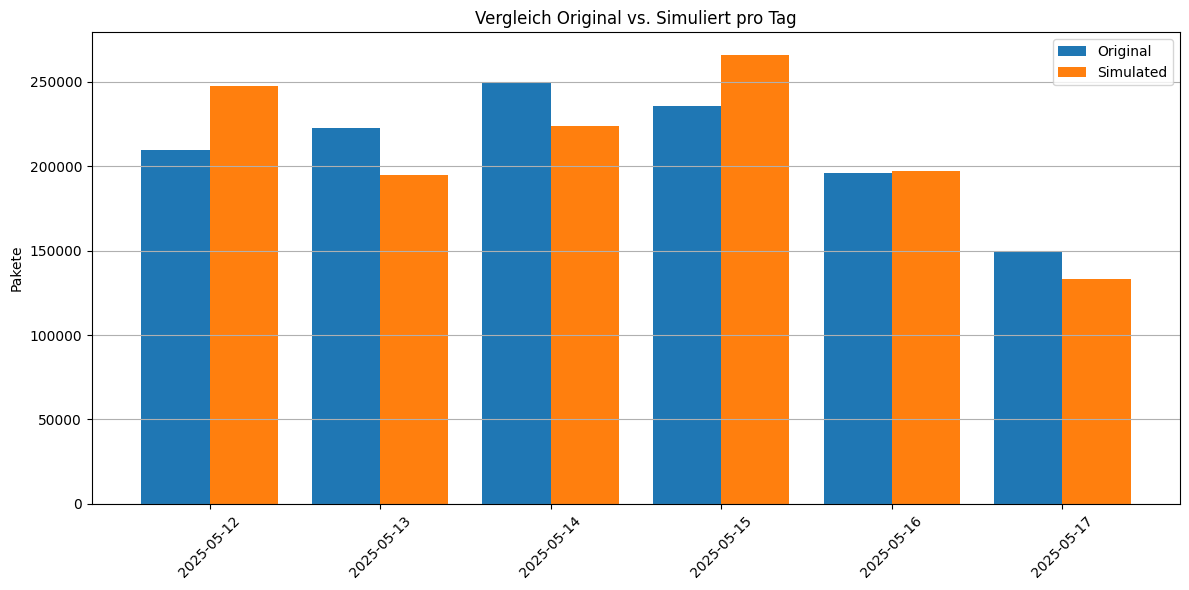

source_day   dest_day   dest_date  b2b_batch  b2c_batch  \
carrier   source_date                                                           
DHL       2025-05-10    Saturday     Monday  2025-05-12       5038       9024   
GLS       2025-05-09      Friday     Monday  2025-05-12        819       2022   
          2025-05-10    Saturday     Monday  2025-05-12        624       1559   
UPS       2025-05-09      Friday     Monday  2025-05-12       9936        544   
          2025-05-10    Saturday     Monday  2025-05-12       7633        439   
FedEx/TNT 2025-05-09      Friday     Monday  2025-05-12       8647        300   
          2025-05-10    Saturday     Monday  2025-05-12       6572        216   
Amazon    2025-05-12      Monday    Tuesday  2025-05-13        189       6372   
DPD       2025-05-10    Saturday    Tuesday  2025-05-13       1947       1549   
          2025-05-12      Monday    Tuesday  2025-05-13       2335       2272   
Hermes    2025-05-12      Monday    Tuesday  2025-05-13        371       3397   
DHL       2025-05-13     Tuesday  Wednesday  2025-05-14       7464      13384   
Amazon    2025-05-14   Wednesday   Thursday  2025-05-15        223       7525   
GLS       2025-05-13     Tuesday   Thursday  2025-05-15        961       2296   
          2025-05-14   Wednesday   Thursday  2025-05-15       1315       2514   
UPS       2025-05-13     Tuesday   Thursday  2025-05-15      11405        661   
          2025-05-14   Wednesday   Thursday  2025-05-15      12648        730   
FedEx/TNT 2025-05-13     Tuesday   Thursday  2025-05-15       9977        339   
          2025-05-14   Wednesday   Thursday  2025-05-15      11061        404   
DHL       2025-05-15    Thursday     Friday  2025-05-16       7888      14283   
DPD       2025-05-14   Wednesday     Friday  2025-05-16       2722       2742   
          2025-05-15    Thursday     Friday  2025-05-16       3008       2445   
Amazon    2025-05-16      Friday   Saturday  2025-05-17        165       5999   
Hermes    2025-05-14   Wednesday   Saturday  2025-05-17        440       3893   
          2025-05-15    Thursday   Saturday  2025-05-17        439       3878   
          2025-05-16      Friday   Saturday  2025-05-17        381       3130   
GLS       2025-05-16      Friday     Monday  2025-05-19        823       2027   
UPS       2025-05-16      Friday     Monday  2025-05-19       9955        555   
FedEx/TNT 2025-05-16      Friday     Monday  2025-05-19       8730        313   
DHL       2025-05-17    Saturday     Monday  2025-05-19       5072       9213   
DPD       2025-05-17    Saturday    Tuesday  2025-05-20       1950       1544   
GLS       2025-05-17    Saturday     Monday  2025-05-19        808       1541   
UPS       2025-05-17    Saturday     Monday  2025-05-19       7635        448   
FedEx/TNT 2025-05-17    Saturday     Monday  2025-05-19       6566        221   

                       b2b_fast  b2c_fast  
carrier   source_date                      
DHL       2025-05-10       2364     44779  
GLS       2025-05-09        383     10026  
          2025-05-10        287      7637  
UPS       2025-05-09       4713      2737  
          2025-05-10       3432      2070  
FedEx/TNT 2025-05-09       4014      1425  
          2025-05-10       2940      1094  
Amazon    2025-05-12         91     31080  
DPD       2025-05-10        861      7760  
          2025-05-12       1079     11301  
Hermes    2025-05-12        193     16275  
DHL       2025-05-13       3407     66639  
Amazon    2025-05-14         95     36997  
GLS       2025-05-13        433     11468  
          2025-05-14        604     12530  
UPS       2025-05-13       5234      3110  
          2025-05-14       5809      3712  
FedEx/TNT 2025-05-13       4505      1651  
          2025-05-14       5015      2013  
DHL       2025-05-15       3593     70541  
DPD       2025-05-14       1306     13464  
          2025-05-15       1390     12337  
Amazon    2025-05-16         99     29116  
Herme

2025-05-01 23:17:21,458 - INFO - Initializing lookup_coords for new_week...
2025-05-01 23:18:57,681 - INFO - Lookup_coords initialized. Loaded 404030 geometries.


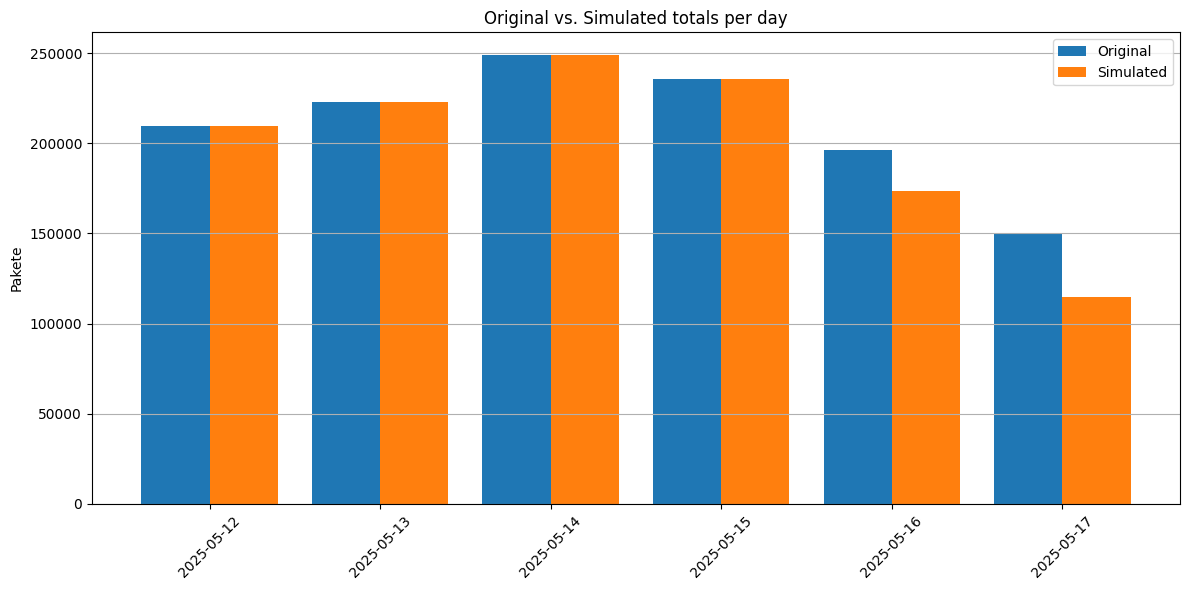

2025-05-01 23:20:35,674 - INFO - ✅ Finished distributing results into new_week
2025-05-01 23:20:35,712 - INFO - Finished simulation for scenario: moderate_cost


In [473]:
new_moderate_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='moderate_cost')

In [458]:
hagrid_files.keys()

dict_keys(['hagrid_parcel_demand_2025-05-09_(Friday)', 'hagrid_parcel_demand_2025-05-10_(Saturday)', 'hagrid_parcel_demand_2025-05-12_(Monday)', 'hagrid_parcel_demand_2025-05-13_(Tuesday)', 'hagrid_parcel_demand_2025-05-14_(Wednesday)', 'hagrid_parcel_demand_2025-05-15_(Thursday)', 'hagrid_parcel_demand_2025-05-16_(Friday)', 'hagrid_parcel_demand_2025-05-17_(Saturday)'])

In [465]:
test = hagrid_files.get("hagrid_parcel_demand_2025-05-16_(Friday)")
test["gls_b2b"].sum(), test["gls_type"].sum()

(1230, 1230)

In [ ]:
new_moderate_week = simulate_full_existing_week(hagrid_files, days = ['Monday'], start_date = datetime.date(2025, 5, 12), scenario='moderate_cost')

Total B2B: 88147, Total B2C: 179525
Sum b2b + b2c: 267672
218874


2025-04-29 21:13:26,329 - INFO - Starting week simulation for scenario: medium_cost
2025-04-29 21:13:26,361 - INFO - Loaded and initialized data for Monday.
2025-04-29 21:13:26,396 - INFO - Loaded and initialized data for Tuesday.
2025-04-29 21:13:26,439 - INFO - Loaded and initialized data for Wednesday.
2025-04-29 21:13:26,474 - INFO - Loaded and initialized data for Thursday.
2025-04-29 21:13:26,510 - INFO - Loaded and initialized data for Friday.
2025-04-29 21:13:26,547 - INFO - Loaded and initialized data for Saturday.
2025-04-29 21:13:26,551 - INFO - Inizializing Coordinates Lookup
2025-04-29 21:14:51,496 - INFO - Coordinates Lookup Created
2025-04-29 21:14:51,498 - INFO -  *** Simulating deliveries for Monday ***
2025-04-29 21:14:51,500 - INFO - Amazon does not has a batch delivery on Monday. Skipping.
2025-04-29 21:14:51,519 - INFO - Source days for DHL: ['Saturday'] with 1 df in days.
2025-04-29 21:14:51,520 - INFO - Starting batch processing for DHL on Monday
2025-04-29 21:14

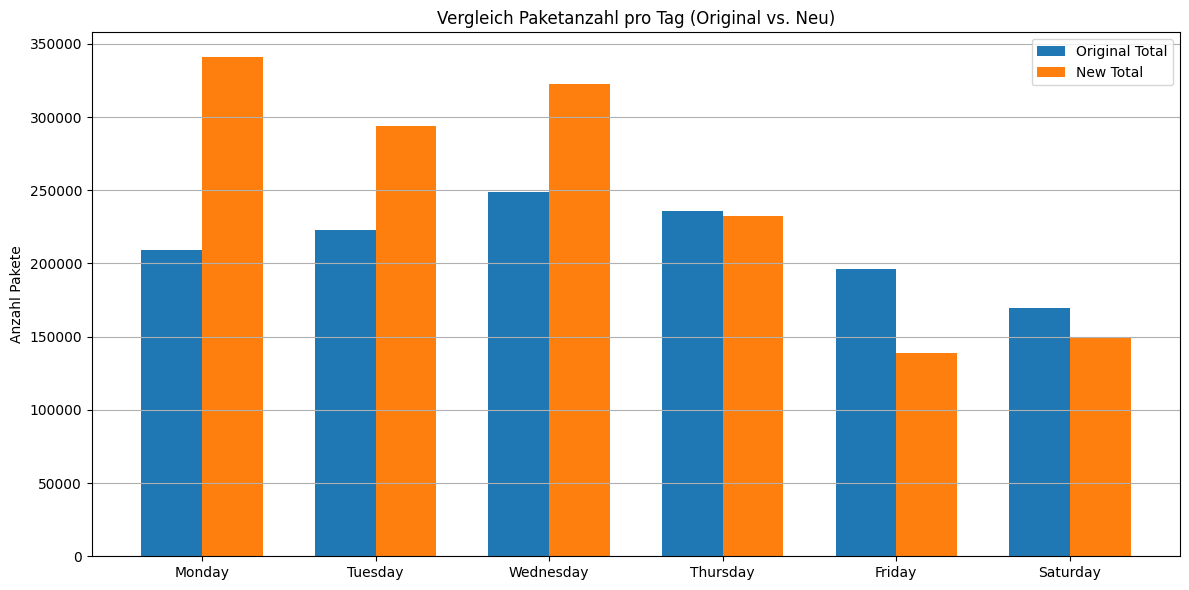

2025-04-29 21:51:38,490 - INFO - Finished simulation for scenario: medium_cost


In [382]:
new_medium_week = simulate_full_existing_week(hagrid_files, days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='medium_cost')

2025-04-29 21:51:38,847 - INFO - Starting week simulation for scenario: high_cost
2025-04-29 21:51:38,868 - INFO - Loaded and initialized data for Monday.
2025-04-29 21:51:38,888 - INFO - Loaded and initialized data for Tuesday.
2025-04-29 21:51:38,910 - INFO - Loaded and initialized data for Wednesday.
2025-04-29 21:51:38,935 - INFO - Loaded and initialized data for Thursday.
2025-04-29 21:51:38,958 - INFO - Loaded and initialized data for Friday.
2025-04-29 21:51:38,978 - INFO - Loaded and initialized data for Saturday.
2025-04-29 21:51:38,979 - INFO - Inizializing Coordinates Lookup
2025-04-29 21:52:59,702 - INFO - Coordinates Lookup Created
2025-04-29 21:52:59,703 - INFO -  *** Simulating deliveries for Monday ***
2025-04-29 21:52:59,704 - INFO - Amazon does not has a batch delivery on Monday. Skipping.
2025-04-29 21:52:59,726 - INFO - Source days for DHL: ['Saturday'] with 1 df in days.
2025-04-29 21:52:59,728 - INFO - Starting batch processing for DHL on Monday
2025-04-29 21:53:0

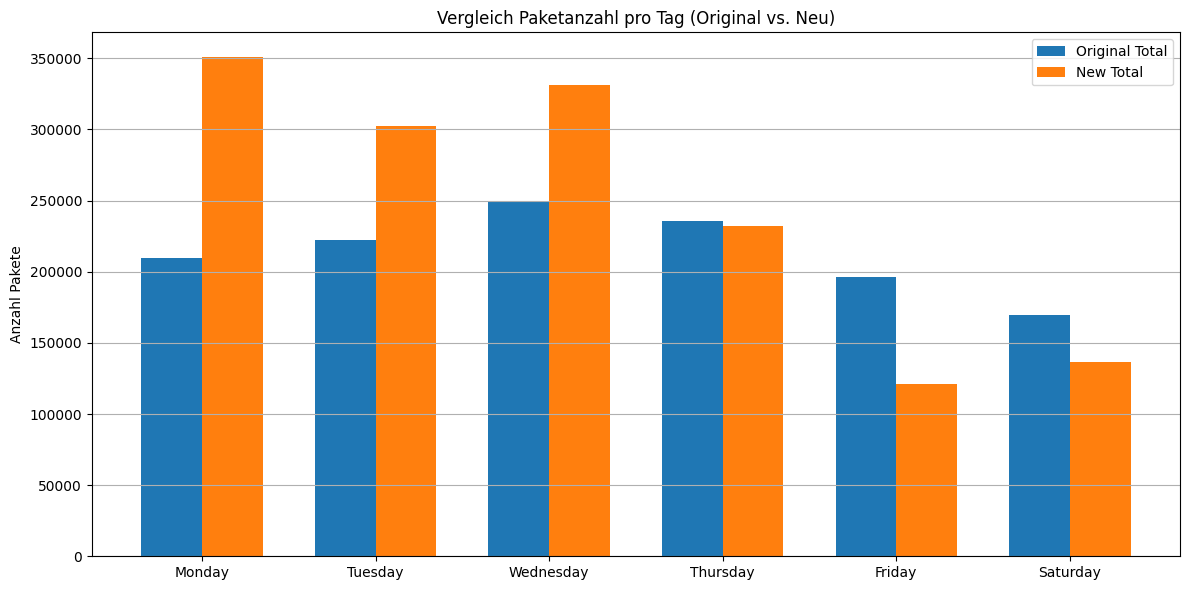

2025-04-29 22:26:21,295 - INFO - Finished simulation for scenario: high_cost


In [383]:
new_high_week = simulate_full_existing_week(hagrid_files, days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='high_cost')

2025-04-29 15:28:57,817 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-29 15:28:57,837 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-29 15:28:57,848 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-29 15:28:57,861 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


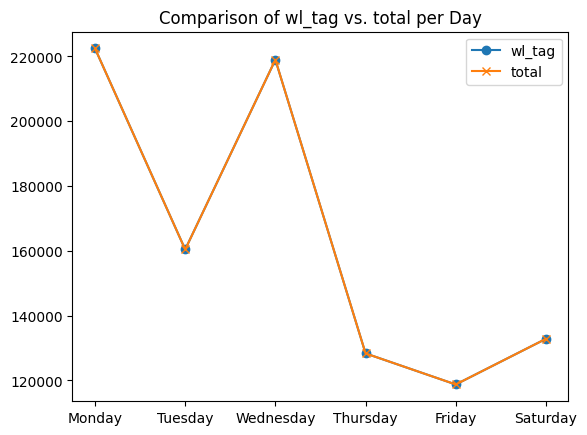

In [277]:
def plot_total_vs_wltag(new_week):
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    wl_tag_totals = []
    total_totals = []

    for day in days:
        df = new_week[day]
        wl_tag_totals.append(df['wl_tag'].sum())
        total_totals.append(df['total'].sum())

    plt.plot(days, wl_tag_totals, marker='o', label='wl_tag')
    plt.plot(days, total_totals, marker='x', label='total')
    plt.title("Comparison of wl_tag vs. total per Day")
    plt.legend()
    plt.show()

plot_total_vs_wltag(new_moderate_week)

2025-04-29 15:29:04,617 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-29 15:29:04,625 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-29 15:29:04,636 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-29 15:29:04,642 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Tuesday Amazon: old=72643, new=73803
Tuesday DHL: old=2589, new=25901
Tuesday DPD: old=18075, new=26735
Tuesday GLS: old=450, new=4488
Tuesday Hermes: old=21553, new=27457
Tuesday UPS: old=128, new=1324
Tuesday FedEx/TNT: old=71, new=721


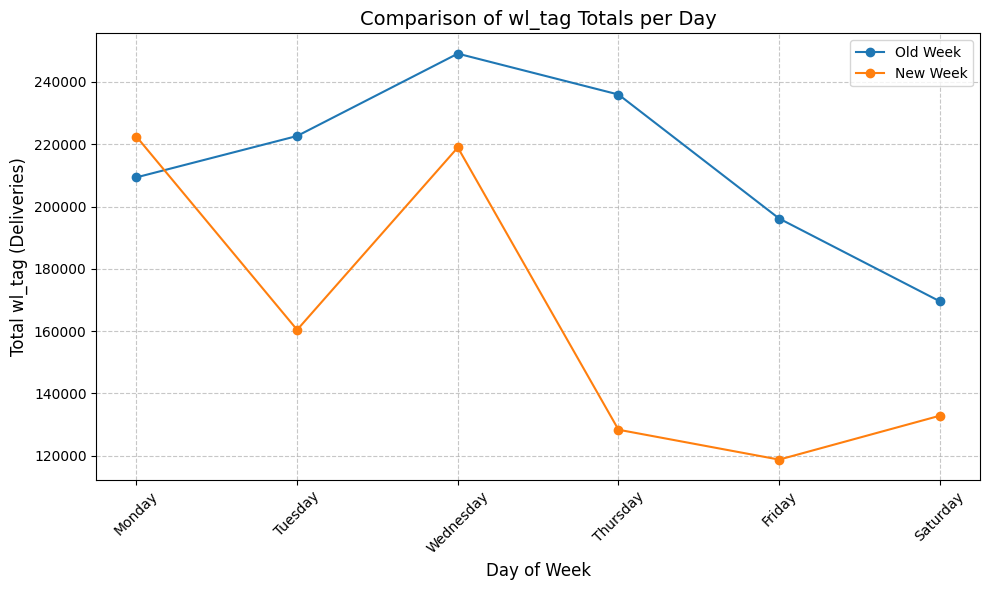

In [278]:
def prepare_old_week(hagrid_files_thisweek, days, base_date):
    """
    Prepares the old (original) week from hagrid_files without simulation changes.
    Calculates wl_tag and total fields.
    """
    old_week = {}

    for i, day in enumerate(days):
        date_str = (base_date + datetime.timedelta(days=i)).strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"
        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")
        
        df = hagrid_files_thisweek[key].copy() 

        old_week[day] = df

    return old_week

def plot_wltag_comparison(old_week, new_week, old_label="Old Week", new_label="New Week"):
    """
    Plots the total wl_tag per day for old and new weeks for comparison.
    """
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    
    old_totals = []
    new_totals = []

    for day in days:
        old_df = old_week.get(day)
        new_df = new_week.get(day)

        if old_df is not None:
            old_total = old_df['wl_tag'].sum()
        else:
            old_total = 0

        if new_df is not None:
            new_total = new_df['wl_tag'].sum()
        else:
            new_total = 0

        old_totals.append(old_total)
        new_totals.append(new_total)

    for carrier in carrier_columns:
        prefix, _, _ = carrier_columns[carrier]
        old_sum = old_week['Tuesday'][f"{prefix}_b2b"].sum() + old_week['Tuesday'][f"{prefix}_b2c"].sum()
        new_sum = new_week['Tuesday'][f"{prefix}_b2b"].sum() + new_week['Tuesday'][f"{prefix}_b2c"].sum()
        print(f"Tuesday {carrier}: old={old_sum}, new={new_sum}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(days, old_totals, marker='o', label=old_label)
    plt.plot(days, new_totals, marker='o', label=new_label)

    plt.title("Comparison of wl_tag Totals per Day", fontsize=14)
    plt.xlabel("Day of Week", fontsize=12)
    plt.ylabel("Total wl_tag (Deliveries)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

old_week = prepare_old_week(hagrid_files, days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], base_date = datetime.date(2025, 5, 12))
plot_wltag_comparison(old_week, new_moderate_week)
